# Chest X-ray AI — SmolVLM-500M-Instruct Integration Test

**Purpose:** validate whether `HuggingFaceTB/SmolVLM-500M-Instruct` can replace
`Qwen/Qwen2.5-VL-3B-Instruct` as the explanation layer for the existing Chest X-ray
pipeline (DenseNet121 classifier + U-Net lung segmentation + Grad-CAM), running on
**CPU**.

This notebook is built directly from your actual `Chest_X_ray_vlm_2.ipynb`. Every
function that has nothing to do with the VLM — preprocessing, Grad-CAM backbone
discovery, the Grad-CAM/lung overlap calculation, evidence-image generation, the
system prompt, JSON parsing, `analyze_xray()`, `ask_about_analysis()`,
`compare_xrays()` — is carried over **unchanged**. Only the VLM loading and
generation mechanics are swapped from Qwen2.5-VL to SmolVLM, plus a few additions
requested for this validation pass: a `VLM_ENABLED` toggle, a CPU performance
benchmark, explicit failure-handling demonstrations, and a final PASS/PARTIAL/FAIL
validation report.

This is a **testing/integration notebook only** — no FastAPI server, no React
frontend, no deployment code. Once validated here, the tested SmolVLM
implementation will be carried over into the server project.

**Do not retrain** the classifier or segmenter — both are loaded from disk as-is.


## 1. Environment Check

In [1]:
import torch

print("Device check")
print("-" * 40)
CUDA_AVAILABLE = torch.cuda.is_available()
print("CUDA available:", CUDA_AVAILABLE)
if CUDA_AVAILABLE:
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected -- this is expected and fully supported here. "
          "SmolVLM-500M-Instruct (unlike the previous Qwen2.5-VL-3B-Instruct) is small "
          "enough to be designed for CPU/on-device use. A GPU will be used automatically "
          "if one is available, but is not required. See the CPU Performance Test section "
          "later in this notebook for concrete timing numbers on your hardware.")


Device check
----------------------------------------
CUDA available: True
GPU name: Tesla T4


## 2. Install Dependencies

Commented out by default so re-running the notebook doesn't reinstall on every run.
Uncomment on a fresh Colab runtime / fresh venv. Note SmolVLM does **not** need the
`qwen-vl-utils` package that Qwen2.5-VL required.

In [2]:
# Uncomment the lines you need on a fresh environment.

%pip install -q "transformers>=4.49" accelerate
%pip install -q pillow opencv-python-headless matplotlib
%pip install -q tensorflow          # Colab ships this by default -- usually not needed
%pip install -q torch --index-url https://download.pytorch.org/whl/cpu   # CPU-only wheel

print("Dependency cell ready (installs are commented out by default).")


Dependency cell ready (installs are commented out by default).


## 3. Imports

In [2]:
import os
import re
import gc
import sys
import time
import json
import uuid
import resource
import traceback
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image

import tensorflow as tf
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess

import torch
import transformers
from transformers import AutoProcessor

# NOTE: unlike Qwen2.5-VL (which needs one specific model class,
# Qwen2_5_VLForConditionalGeneration, and the qwen-vl-utils helper package), SmolVLM loads
# correctly with either of two Transformers model classes depending on the installed
# version. Rather than hard-importing one class here and failing loudly if it's absent
# (as the original notebook did for Qwen2_5_VLForConditionalGeneration), the "Load
# SmolVLM" section below inspects the installed Transformers version and tries the modern
# class first, falling back automatically -- see load_smolvlm(). No extra vision-utility
# package (equivalent to qwen-vl-utils) is required for SmolVLM.

# IMPROVEMENT 12 (GPU memory): prevent TensorFlow from pre-allocating all GPU memory, since
# TensorFlow (classifier + segmenter) and PyTorch (VLM) must share the same GPU in this
# notebook. Safe to ignore the warning below if no GPU is present.
try:
    _gpus = tf.config.experimental.list_physical_devices("GPU")
    for _gpu in _gpus:
        tf.config.experimental.set_memory_growth(_gpu, True)
    if _gpus:
        print(f"TensorFlow: enabled memory growth on {len(_gpus)} GPU(s).")
except Exception as e:
    print(f"Could not configure TensorFlow GPU memory growth (safe to ignore if no GPU): {e}")


TensorFlow: enabled memory growth on 1 GPU(s).


## 4. Mount Google Drive

Optional / Colab-only. Already wrapped in a `try/except` so it's a no-op outside
Colab.

In [3]:
from google.colab import drive

try:
    drive.mount('/content/drive')
    DRIVE_MOUNTED = os.path.isdir('/content/drive/MyDrive')
except Exception as e:
    print(f"Google Drive mount failed or not running in Colab: {e}")
    DRIVE_MOUNTED = False


Mounted at /content/drive


## 5. Configuration & Device Detection

In [4]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
tf.random.set_seed(SEED)

# ---- Existing, already-trained models (DO NOT retrain) ----
CLASSIFICATION_MODEL_PATH = "/content/drive/MyDrive/artifacts/classifier_stage2_best.keras"
SEGMENTATION_MODEL_PATH = "/content/drive/MyDrive/artifacts/segmenter_best.keras"

# IMPROVEMENT 17: explicit model/version identifiers, saved into every analysis's metadata.
CLASSIFIER_NAME = "DenseNet121"
CLASSIFIER_VERSION = "stage2_best"
SEGMENTER_NAME = "U-Net"
SEGMENTER_VERSION = "segmenter_best"

# ---- VLM under test: swapped from Qwen/Qwen2.5-VL-3B-Instruct -> SmolVLM-500M-Instruct ----
VLM_MODEL_NAME = "HuggingFaceTB/SmolVLM-500M-Instruct"

# Set to False to run DenseNet + U-Net + Grad-CAM only, with the VLM explanation step
# skipped entirely (status "disabled" everywhere it would otherwise appear). Useful for
# quickly testing/iterating on the classical pipeline without paying VLM load/inference cost.
VLM_ENABLED = True

IMG_SIZE = 224
CLASS_NAMES = ["COVID", "Lung_Opacity", "Normal", "Viral Pneumonia"]
NUM_CLASSES = len(CLASS_NAMES)
MASK_THRESHOLD = 0.5

# High-activation threshold used when translating a Grad-CAM heatmap into a plain-language
# region description -- matches the threshold used in the original training notebook.
GRADCAM_REGION_THRESHOLD = 0.6

# Configurable fallback layer name for Grad-CAM, only used if automatic backbone/4D-layer
# discovery fails (see the Grad-CAM Backbone Discovery section). Not required by default --
# generate_gradcam() discovers the backbone automatically without hardcoding names.
GRADCAM_FALLBACK_LAYER = "densenet121"

# ---------------------------------------------------------------------------------------
# IMPROVEMENT 2: unique, never-overwritten artifact directories. Prefers Google Drive (so
# analyses persist across Colab sessions) when mounted, and falls back to local disk so the
# notebook still runs if Drive is unavailable. Configurable via the VLM_ARTIFACTS_DIR env var.
# ---------------------------------------------------------------------------------------
def _resolve_artifacts_root():
    if os.path.isdir("/content/drive/MyDrive"):
        return "/content/drive/MyDrive/artifacts/vlm"
    return "artifacts/vlm"

VLM_ARTIFACTS_DIR = os.environ.get("VLM_ARTIFACTS_DIR", _resolve_artifacts_root())
os.makedirs(VLM_ARTIFACTS_DIR, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Reproducibility / environment info")
print("-" * 40)
print("TensorFlow version:  ", tf.__version__)
print("PyTorch version:     ", torch.__version__)
print("Transformers version:", transformers.__version__)
print("CUDA available:      ", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:            ", torch.cuda.get_device_name(0))
print("Device:               ", DEVICE.upper())
print("VLM model:            ", VLM_MODEL_NAME)
print("VLM_ENABLED:          ", VLM_ENABLED)
print("Classifier path:      ", CLASSIFICATION_MODEL_PATH)
print("Segmentation path:    ", SEGMENTATION_MODEL_PATH)
print("Artifacts directory:  ", VLM_ARTIFACTS_DIR)


Reproducibility / environment info
----------------------------------------
TensorFlow version:   2.20.0
PyTorch version:      2.11.0+cu128
Transformers version: 5.16.1
CUDA available:       True
GPU name:             Tesla T4
Device:                CUDA
VLM model:             HuggingFaceTB/SmolVLM-500M-Instruct
VLM_ENABLED:           True
Classifier path:       /content/drive/MyDrive/artifacts/classifier_stage2_best.keras
Segmentation path:     /content/drive/MyDrive/artifacts/segmenter_best.keras
Artifacts directory:   /content/drive/MyDrive/artifacts/vlm


## 6. Utility Helpers

In [5]:
def require_file(path, what):
    if not os.path.exists(path):
        raise FileNotFoundError(f"{what} not found at: {path}")

def safe_load_pil_image(path):
    require_file(path, "Image")
    try:
        return Image.open(path).convert("RGB")
    except Exception as e:
        raise ValueError(f"Could not open '{path}' as an image: {e}")

def clear_gpu_memory():
    """Call after heavy VLM generation calls if you're iterating over many images in a
    loop, to avoid unnecessarily accumulating GPU memory. Not called after every single
    step internally, to avoid unnecessarily slowing down inference (IMPROVEMENT 12)."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

def make_analysis_id():
    """Unique, sortable analysis ID: timestamp + short UUID suffix, so concurrent analyses
    in the same second still get distinct IDs/directories (IMPROVEMENT 2)."""
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    short_uuid = uuid.uuid4().hex[:8]
    return f"analysis_{ts}_{short_uuid}"

def new_analysis_dir(analysis_id=None, root=None):
    """Create (and return) a fresh directory for one analysis run. Never reuses/overwrites
    a previous analysis's directory."""
    if analysis_id is None:
        analysis_id = make_analysis_id()
    if root is None:
        root = VLM_ARTIFACTS_DIR
    path = os.path.join(root, analysis_id)
    os.makedirs(path, exist_ok=True)
    return analysis_id, path


## 7. Load Classifier

Loads the existing, already-trained DenseNet121 classifier exactly as before.
**Not retrained here.**

In [6]:
CLASSIFIER_LOAD_ERROR = None
classifier = None
try:
    require_file(CLASSIFICATION_MODEL_PATH, "Classification model")
    classifier = tf.keras.models.load_model(CLASSIFICATION_MODEL_PATH)
    classifier.trainable = False  # inference only -- this model is already trained, do not retrain it

    print("Loaded classifier:")
    print(" ", CLASSIFICATION_MODEL_PATH)
    print("Input shape:", classifier.input_shape, " Output shape:", classifier.output_shape)
    print("\nLoaded classifier architecture (top-level layers):")
    for l in classifier.layers:
        print(f"  {l.name:30s} {str(getattr(l, 'output_shape', None)):30s} ({type(l).__name__})")
except Exception as e:
    CLASSIFIER_LOAD_ERROR = str(e)
    print(f"WARNING: failed to load classifier: {e}")

def classifier_is_available():
    return classifier is not None


Loaded classifier:
  /content/drive/MyDrive/artifacts/classifier_stage2_best.keras
Input shape: (None, 224, 224, 3)  Output shape: (None, 4)

Loaded classifier architecture (top-level layers):
  input_layer_1                  None                           (InputLayer)
  densenet121                    (None, 7, 7, 1024)             (Functional)
  gap                            None                           (GlobalAveragePooling2D)
  batch_normalization            None                           (BatchNormalization)
  dropout                        None                           (Dropout)
  dense                          None                           (Dense)
  dropout_1                      None                           (Dropout)
  predictions                    None                           (Dense)


## 8. Load Segmentation Model

In [7]:
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coefficient(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    bce = tf.reduce_mean(tf.keras.losses.binary_crossentropy(y_true, y_pred))
    return bce + dice_loss(y_true, y_pred)

def iou_metric(y_true, y_pred, smooth=1e-6, threshold=0.5):
    y_pred_bin = tf.cast(y_pred > threshold, tf.float32)
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred_bin, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

SEGMENTER_LOAD_ERROR = None
segmenter = None
try:
    require_file(SEGMENTATION_MODEL_PATH, "Segmentation model")
    segmenter = tf.keras.models.load_model(
        SEGMENTATION_MODEL_PATH,
        custom_objects={
            "bce_dice_loss": bce_dice_loss,
            "dice_coefficient": dice_coefficient,
            "iou_metric": iou_metric,
            "dice_loss": dice_loss,
        },
    )
    segmenter.trainable = False  # inference only -- this model is already trained, do not retrain it

    print("Segmenter loaded from:", SEGMENTATION_MODEL_PATH)
    print("Input shape:", segmenter.input_shape, " Output shape:", segmenter.output_shape)
except Exception as e:
    SEGMENTER_LOAD_ERROR = str(e)
    print(f"WARNING: failed to load segmenter: {e}")

def segmenter_is_available():
    return segmenter is not None


Segmenter loaded from: /content/drive/MyDrive/artifacts/segmenter_best.keras
Input shape: (None, 224, 224, 3)  Output shape: (None, 224, 224, 1)


## 9. Load SmolVLM

Replaces the Qwen2.5-VL-3B-Instruct loading cell. Inspects the installed
`transformers` version and picks a compatible loading path rather than assuming
one API: current releases expose the unified `AutoModelForImageTextToText` class
for image-text-to-text models, while the class SmolVLM originally shipped with was
`AutoModelForVision2Seq`. This cell tries the modern class first and falls back
automatically. Gated by `VLM_ENABLED` from the Configuration cell.

In [8]:
VLM_LOAD_ERROR = None
vlm_processor = None
vlm_model = None
vlm_load_time = None
VLM_MODEL_CLASS_USED = None


def load_smolvlm():
    '''Load SmolVLM in a way that is compatible with whichever Transformers version is
    installed, rather than assuming one API. Tries the modern unified
    AutoModelForImageTextToText class first (the current recommended class for
    image-text-to-text models); falls back to AutoModelForVision2Seq (the class used at
    SmolVLM's original release, and still valid) if that import or load fails. Never
    raises -- failures are captured in VLM_LOAD_ERROR so the rest of the pipeline
    (classification, segmentation, Grad-CAM) keeps working (IMPROVEMENT 11).'''
    global vlm_model, vlm_processor, VLM_LOAD_ERROR, vlm_load_time, VLM_MODEL_CLASS_USED

    t0 = time.time()
    try:
        # bfloat16 on GPU for speed/memory; float32 on CPU since not all CPU kernels
        # support bf16 well and CPU is this notebook's default, primary target.
        vlm_dtype = torch.bfloat16 if torch.cuda.is_available() else torch.float32

        vlm_processor = AutoProcessor.from_pretrained(VLM_MODEL_NAME)

        model = None
        last_error = None

        try:
            from transformers import AutoModelForImageTextToText
            model = AutoModelForImageTextToText.from_pretrained(
                VLM_MODEL_NAME, torch_dtype=vlm_dtype, _attn_implementation="eager",
            )
            VLM_MODEL_CLASS_USED = "AutoModelForImageTextToText"
        except Exception as e:
            last_error = e
            model = None

        if model is None:
            try:
                from transformers import AutoModelForVision2Seq
                model = AutoModelForVision2Seq.from_pretrained(
                    VLM_MODEL_NAME, torch_dtype=vlm_dtype, _attn_implementation="eager",
                )
                VLM_MODEL_CLASS_USED = "AutoModelForVision2Seq"
            except Exception as e:
                last_error = e
                model = None

        if model is None:
            raise last_error if last_error is not None else RuntimeError(
                "Could not load SmolVLM with either AutoModelForImageTextToText or "
                "AutoModelForVision2Seq."
            )

        # INFERENCE ONLY: eval() disables dropout/batchnorm-update behavior; no optimizer is
        # ever created and no gradients are computed for this model's parameters anywhere in
        # this notebook.
        vlm_model = model.to(DEVICE)
        vlm_model.eval()
        vlm_load_time = time.time() - t0

        print(f"Loaded {VLM_MODEL_NAME} via {VLM_MODEL_CLASS_USED} in {vlm_load_time:.2f}s "
              f"on device: {DEVICE}")
        print(f"dtype: {vlm_dtype}")
        return True

    except Exception as e:
        VLM_LOAD_ERROR = str(e)
        print(f"WARNING: failed to load VLM ({VLM_MODEL_NAME}): {e}")
        print("Classification, segmentation, and Grad-CAM will still work fully. VLM-dependent "
              "calls will return a 'vlm_unavailable'/'vlm_error' status instead of crashing "
              "(IMPROVEMENT 11).")
        return False


def vlm_is_available():
    return vlm_model is not None and vlm_processor is not None


print(f"Detected Transformers version: {transformers.__version__}")
if VLM_ENABLED:
    load_smolvlm()
else:
    print("VLM_ENABLED is False -- skipping SmolVLM load. The pipeline will run with the "
          "VLM step skipped (status 'disabled') everywhere it would otherwise appear.")


Detected Transformers version: 5.16.1


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/429 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/7.34k [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.02GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/489 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

Loaded HuggingFaceTB/SmolVLM-500M-Instruct via AutoModelForImageTextToText in 18.87s on device: cuda
dtype: torch.bfloat16


## 10. Image Loading & Classification Inference

`load_raw_image_for_display`, `predict_classification` — unchanged from the source
notebook. DenseNet preprocessing (`densenet_preprocess`) is untouched.

In [10]:
def load_raw_image_for_display(image_path, size=IMG_SIZE):
    require_file(image_path, "Image")
    try:
        img = tf.io.read_file(image_path)
        img = tf.io.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, [size, size])
        return tf.cast(img, tf.uint8).numpy()
    except Exception as e:
        raise ValueError(f"Could not decode '{image_path}' as an image: {e}") from e


def predict_classification(image_path, model=None):
    """Python is the SOLE source of truth for predicted_class / confidence / probabilities
    (IMPROVEMENT 1). The VLM never generates or overrides these values -- see
    generate_vlm_explanation(), which strips any numeric fields the VLM might hallucinate."""
    if model is None:
        if not classifier_is_available():
            raise RuntimeError(f"Classifier unavailable: {CLASSIFIER_LOAD_ERROR}")
        model = classifier

    raw_img = load_raw_image_for_display(image_path)

    # MUST match the classifier's training-time preprocessing exactly -- unchanged.
    preprocessed = densenet_preprocess(tf.cast(raw_img, tf.float32))
    img_array = tf.expand_dims(preprocessed, axis=0)

    probs = model.predict(img_array, verbose=0)[0]
    pred_index = int(np.argmax(probs))

    return {
        "predicted_class": CLASS_NAMES[pred_index],
        "predicted_class_index": pred_index,
        "confidence": float(probs[pred_index]),
        "probabilities": {CLASS_NAMES[i]: float(probs[i]) for i in range(NUM_CLASSES)},
    }


Smoke test (skips automatically if the example image isn't present yet):

In [11]:
# Example / smoke test -- skipped automatically if TEST_IMAGE_PATH does not exist yet.
_example_image = "/content/Screenshot 2026-09-12 231143.png"
if classifier_is_available() and os.path.exists(_example_image):
    print(predict_classification(_example_image))
else:
    print("Skipping classification smoke test -- classifier unavailable or example image "
          f"not found at {_example_image}. This is expected until you provide a real image "
          "path (see SECTION 18 -- Testing).")


{'predicted_class': 'COVID', 'predicted_class_index': 0, 'confidence': 0.9995907545089722, 'probabilities': {'COVID': 0.9995907545089722, 'Lung_Opacity': 0.00017911721079144627, 'Normal': 0.0002301266067661345, 'Viral Pneumonia': 2.0773933684381518e-08}}


## 11. Segmentation Inference

In [12]:
def predict_segmentation(image_path, gt_mask_path=None, threshold=MASK_THRESHOLD, save_dir=None):
    if not segmenter_is_available():
        raise RuntimeError(f"Segmentation unavailable: segmenter failed to load ({SEGMENTER_LOAD_ERROR}).")

    save_dir = save_dir or VLM_ARTIFACTS_DIR
    os.makedirs(save_dir, exist_ok=True)

    raw_img = load_raw_image_for_display(image_path)
    img_norm = tf.cast(raw_img, tf.float32) / 255.0  # exact segmenter preprocessing from training

    pred_mask = segmenter.predict(tf.expand_dims(img_norm, 0), verbose=0)[0]
    pred_mask_bin = (pred_mask > threshold).astype(np.float32)

    # Lung segmentation overlay (original + lung region highlighted) -- distinct from the
    # binary mask image saved below (IMPROVEMENT 5).
    overlay = raw_img.copy()
    overlay[..., 0] = np.where(pred_mask_bin.squeeze() > 0.5, 255, overlay[..., 0])

    mask_path = os.path.join(save_dir, "lung_mask.png")
    overlay_path = os.path.join(save_dir, "lung_segmentation.png")
    plt.imsave(mask_path, pred_mask_bin.squeeze(), cmap="gray")
    plt.imsave(overlay_path, overlay)

    result = {
        "mask": pred_mask_bin,
        "mask_path": mask_path,
        "overlay_path": overlay_path,
        "dice": None,
        "iou": None,
    }

    # Only compute Dice/IoU if ground truth is actually available -- never fabricated, and
    # never computed for a plain inference-time image with no ground-truth mask.
    if gt_mask_path is not None and os.path.exists(gt_mask_path):
        gt_mask = tf.io.read_file(gt_mask_path)
        gt_mask = tf.io.decode_image(gt_mask, channels=1, expand_animations=False)
        gt_mask = tf.image.resize(gt_mask, [IMG_SIZE, IMG_SIZE], method="nearest")
        gt_mask = tf.cast(gt_mask, tf.float32) / 255.0
        gt_mask = tf.cast(gt_mask > 0.5, tf.float32)

        result["dice"] = float(dice_coefficient(gt_mask, pred_mask).numpy())
        result["iou"] = float(iou_metric(gt_mask, pred_mask).numpy())

    return result


In [13]:
# Example / smoke test
if segmenter_is_available() and os.path.exists(_example_image):
    _seg = predict_segmentation(_example_image)
    print("mask_path:", _seg["mask_path"])
    print("overlay_path:", _seg["overlay_path"])
else:
    print("Skipping segmentation smoke test -- segmenter unavailable or example image not found.")


mask_path: /content/drive/MyDrive/artifacts/vlm/lung_mask.png
overlay_path: /content/drive/MyDrive/artifacts/vlm/lung_segmentation.png


## 12. Grad-CAM — Backbone Discovery

Locates the nested DenseNet121 backbone inside the classifier **without hardcoding
its name**, and validates it produces a spatial 4D feature map.

In [14]:
def _find_backbone_layer(model, fallback_name=None):
    """Locate the nested CNN backbone (e.g. the DenseNet121 sub-model) inside the outer
    classifier, WITHOUT hardcoding its name. Falls back to `fallback_name`
    (GRADCAM_FALLBACK_LAYER) only if automatic detection is ambiguous."""
    nested_models = [l for l in model.layers if isinstance(l, tf.keras.Model)]

    # Prefer a nested backbone whose own output is already a 4D (H, W, C) feature map --
    # true for any `include_top=False` DenseNet121/ResNet/etc backbone.
    for backbone in nested_models:
        out_shape = backbone.output_shape
        if isinstance(out_shape, list):
            out_shape = out_shape[0]
        if out_shape is not None and len(out_shape) == 4:
            return backbone

    if fallback_name is not None:
        try:
            candidate = model.get_layer(fallback_name)
            if isinstance(candidate, tf.keras.Model):
                return candidate
        except ValueError:
            pass
    return None


def _validate_spatial_layer(output_shape, layer_name):
    shape = output_shape
    if isinstance(shape, list):
        shape = shape[0]
    if shape is None or len(shape) != 4:
        raise ValueError(
            f"Grad-CAM target layer '{layer_name}' does not produce a spatial 4D "
            f"(batch, H, W, C) feature map (got output_shape={shape}). Grad-CAM requires "
            f"a convolutional/spatial feature map -- run inspect_classifier_layers() and "
            f"set GRADCAM_FALLBACK_LAYER to the correct layer name if needed."
        )


def inspect_classifier_layers(model=None):
    """Diagnostic helper: run this if generate_gradcam() can't find/connect a spatial
    feature layer for your specific saved model, and inspect the printed structure."""
    if model is None:
        model = classifier
    print(f"Top-level layers in '{model.name}':")
    for l in model.layers:
        print(f"  {l.name:30s} {str(getattr(l, 'output_shape', None)):25s} ({type(l).__name__})")
    for l in model.layers:
        if isinstance(l, tf.keras.Model):
            print(f"\nNested backbone '{l.name}' has {len(l.layers)} internal layers. Last 10:")
            for inner in l.layers[-10:]:
                print(f"  {inner.name:30s} {getattr(inner, 'output_shape', None)}")


## 13. Grad-CAM

Single `tf.GradientTape`, manual layer-by-layer replay of the classifier's forward
path (backbone → head layers, in original definition order) — no secondary
`tf.keras.Model` is built around symbolic tensors from the reloaded nested
DenseNet, which is what caused the Keras 3 disconnected-graph problem this design
avoids. Grad-CAM here means **"where the classifier is focusing"** — not an exact
disease location, not a lesion segmentation. The U-Net is not computationally
connected to the classifier; both remain independent and are only combined
geometrically, after inference.

In [15]:
def generate_gradcam(image_path, classifier_model=None, class_index=None, save_dir=None):
    """
    Grad-CAM for the already-trained DenseNet121 classifier. See the SECTION 9 markdown
    cell above for the Keras-compatibility design rationale.

    Grad-CAM remains a CORE component of this project: its purpose is to show which image
    regions contributed to the classifier's prediction, and (via
    calculate_gradcam_lung_overlap) how much of that activation falls inside the U-Net's
    predicted lung region. It is NOT disease/lesion segmentation, and the U-Net is NOT
    computationally connected to the DenseNet classifier -- both models remain independent
    and are only combined, geometrically, after inference.
    """
    if classifier_model is None:
        if not classifier_is_available():
            raise RuntimeError(f"Grad-CAM unavailable: classifier failed to load ({CLASSIFIER_LOAD_ERROR}).")
        classifier_model = classifier

    save_dir = save_dir or VLM_ARTIFACTS_DIR
    os.makedirs(save_dir, exist_ok=True)

    raw_img = load_raw_image_for_display(image_path)
    preprocessed = densenet_preprocess(tf.cast(raw_img, tf.float32))
    img_array = tf.expand_dims(preprocessed, axis=0)

    # --- Automatically identify the backbone / final conv feature layer -------------
    backbone = _find_backbone_layer(classifier_model, fallback_name=GRADCAM_FALLBACK_LAYER)
    if backbone is None:
        raise ValueError(
            "Grad-CAM failed: could not automatically locate a nested convolutional backbone "
            f"in '{classifier_model.name}', and fallback layer "
            f"'{GRADCAM_FALLBACK_LAYER}' was not found either. Run inspect_classifier_layers() "
            "and set GRADCAM_FALLBACK_LAYER to the correct layer name."
        )
    _validate_spatial_layer(backbone.output_shape, backbone.name)
    print(f"[Grad-CAM] Using backbone/feature layer: '{backbone.name}' "
          f"(output_shape={backbone.output_shape})")

    # --- Identify the classifier-head layers that follow the backbone, in order -----
    all_layers = classifier_model.layers
    backbone_idx = all_layers.index(backbone)
    head_layers = [l for l in all_layers[backbone_idx + 1:]
                   if not isinstance(l, tf.keras.layers.InputLayer)]
    if not head_layers:
        raise ValueError(
            f"Grad-CAM failed: no classification-head layers found after backbone "
            f"'{backbone.name}'. Run inspect_classifier_layers() to inspect the model."
        )
    print(f"[Grad-CAM] Replaying {len(head_layers)} head layer(s) in original order: "
          + " -> ".join(l.name for l in head_layers))

    # --- Single GradientTape covering backbone + head (see design note above) -------
    with tf.GradientTape() as tape:
        conv_outputs = backbone(img_array, training=False)
        tape.watch(conv_outputs)

        x = conv_outputs
        for layer in head_layers:
            try:
                x = layer(x, training=False)
            except Exception as e:
                raise RuntimeError(
                    f"Grad-CAM failed while replaying head layer '{layer.name}' "
                    f"({type(layer).__name__}): {e}. This classifier head may not be a "
                    f"simple sequential stack after the backbone -- inspect with "
                    f"inspect_classifier_layers() and adapt generate_gradcam() if needed."
                ) from e
        predictions = x

        if class_index is None:
            class_index = int(tf.argmax(predictions[0]))
        class_channel = predictions[:, class_index]

    grads = tape.gradient(class_channel, conv_outputs)

    if grads is None:
        raise RuntimeError(
            "Grad-CAM failed: gradients are None. The backbone feature map is not connected "
            "to the classifier output inside the GradientTape. This usually means the head "
            "layers were not replayed in the correct order -- run inspect_classifier_layers() "
            "and check the printed layer order above."
        )

    # --- Weighted feature maps -> heatmap --------------------------------------------
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs_b0 = conv_outputs[0]
    heatmap = conv_outputs_b0 @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0)                       # ReLU
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)    # normalize
    heatmap = heatmap.numpy()

    heatmap_resized = cv2.resize(heatmap, (raw_img.shape[1], raw_img.shape[0]))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(raw_img, 0.6, heatmap_color, 0.4, 0)

    heatmap_path = os.path.join(save_dir, "gradcam_heatmap.png")
    overlay_path = os.path.join(save_dir, "gradcam.png")
    plt.imsave(heatmap_path, heatmap_resized, cmap="jet")
    plt.imsave(overlay_path, overlay)

    return {
        "heatmap": heatmap_resized,
        "overlay": overlay,
        "heatmap_path": heatmap_path,
        "overlay_path": overlay_path,
        "target_class": CLASS_NAMES[class_index],
        "target_class_index": class_index,
        "probabilities": predictions.numpy()[0],
        "confidence": float(predictions.numpy()[0][class_index]),
        "gradcam_layer": backbone.name,
    }


[Grad-CAM] Using backbone/feature layer: 'densenet121' (output_shape=(None, 7, 7, 1024))
[Grad-CAM] Replaying 6 head layer(s) in original order: gap -> batch_normalization -> dropout -> dense -> dropout_1 -> predictions
Target class: COVID
Confidence: 0.9995908141136169
Grad-CAM layer used: densenet121
Heatmap: /content/drive/MyDrive/artifacts/vlm/gradcam_heatmap.png
Overlay: /content/drive/MyDrive/artifacts/vlm/gradcam.png


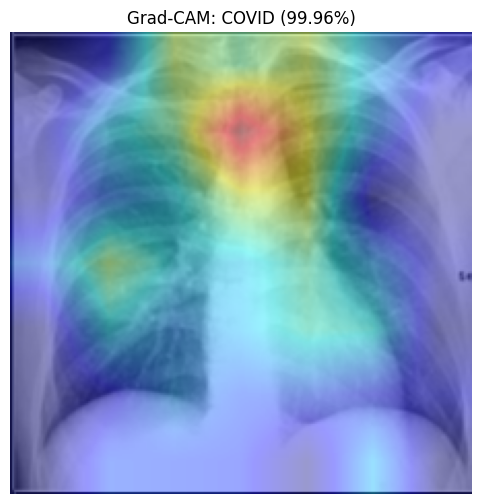

In [16]:
# Example / smoke test -- run Grad-CAM BEFORE any VLM call, per the project's validation
# sequence: generate_gradcam() -> verify heatmap -> predict_segmentation() ->
# calculate_gradcam_lung_overlap() -> create_vlm_evidence_images() -> generate_vlm_explanation().
if classifier_is_available() and os.path.exists(_example_image):
    _out = generate_gradcam(_example_image)
    print("Target class:", _out["target_class"])
    print("Confidence:", _out["confidence"])
    print("Grad-CAM layer used:", _out["gradcam_layer"])
    print("Heatmap:", _out["heatmap_path"])
    print("Overlay:", _out["overlay_path"])

    plt.figure(figsize=(6, 6))
    plt.imshow(_out["overlay"])
    plt.axis("off")
    plt.title(f"Grad-CAM: {_out['target_class']} ({_out['confidence']*100:.2f}%)")
    plt.show()
else:
    print("Skipping Grad-CAM smoke test -- classifier unavailable or example image not found.")


## 14. Grad-CAM / Lung Overlap

`overlap = (Grad-CAM activation inside the predicted lung region) / (total Grad-CAM
activation)` — an activation-weighted geometric comparison, **not** a disease
percentage and **not** a localization-accuracy score.

In [17]:
def calculate_gradcam_lung_overlap(gradcam_heatmap, lung_mask):
    """
    overlap = (Grad-CAM activation inside the predicted lung region) / (total Grad-CAM activation)

    This is a purely GEOMETRIC comparison of two arrays -- it does not confirm, rule out, or
    grade any medical finding. Label it "Grad-CAM/lung overlap" or "activation overlap with
    predicted lung region" -- never "Grad-CAM accuracy" or "(medical/lesion) localization
    accuracy" (IMPROVEMENT 3/4 + the Grad-CAM correction notes).
    """
    heatmap = np.asarray(gradcam_heatmap, dtype=np.float32)
    mask = np.asarray(lung_mask, dtype=np.float32).squeeze()

    if mask.shape != heatmap.shape:
        mask = cv2.resize(mask, (heatmap.shape[1], heatmap.shape[0]))

    total_activation = float(heatmap.sum())
    if total_activation <= 0:
        return {"overlap": 0.0, "overlap_percentage": 0.0}

    inside_activation = float((heatmap * mask).sum())
    overlap = inside_activation / total_activation
    overlap = float(np.clip(overlap, 0.0, 1.0))

    return {"overlap": overlap, "overlap_percentage": overlap * 100.0}


def describe_activation_region(heatmap, threshold=GRADCAM_REGION_THRESHOLD):
    """Plain geometric description of WHERE the Grad-CAM heatmap is concentrated. NOT a
    medical finding -- purely a description of pixel activation location."""
    ys, xs = np.where(heatmap >= threshold)
    if len(ys) == 0:
        return "diffuse regions across the lung fields"

    h, w = heatmap.shape
    cy, cx = ys.mean() / h, xs.mean() / w
    vertical = "upper" if cy < 0.33 else ("lower" if cy > 0.66 else "central")
    horizontal = "left" if cx < 0.33 else ("right" if cx > 0.66 else "central")

    if vertical == "central" and horizontal == "central":
        return "central lung field"
    return f"{vertical}-{horizontal} lung field"


## 15. Evidence Image Generation

In [18]:
def create_vlm_evidence_images(image_path, analysis_dir):
    """Generates and saves ALL evidence images (original, binary lung mask, lung
    segmentation overlay, Grad-CAM heatmap + overlay, a combined 4-panel figure) into
    `analysis_dir` -- a unique per-analysis directory from new_analysis_dir() (IMPROVEMENT
    2). Nothing here is ever overwritten by a later analysis run."""
    os.makedirs(analysis_dir, exist_ok=True)

    raw_img = load_raw_image_for_display(image_path)
    original_path = os.path.join(analysis_dir, "original.png")
    plt.imsave(original_path, raw_img)

    segmentation_result = predict_segmentation(image_path, save_dir=analysis_dir)
    gradcam_result = generate_gradcam(image_path, save_dir=analysis_dir)
    overlap_result = calculate_gradcam_lung_overlap(gradcam_result["heatmap"], segmentation_result["mask"])
    activation_region = describe_activation_region(gradcam_result["heatmap"])

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    axes[0].imshow(raw_img)
    axes[0].set_title("Original X-ray")
    axes[0].axis("off")
    axes[1].imshow(segmentation_result["mask"].squeeze(), cmap="gray")
    axes[1].set_title("Binary Lung Mask")
    axes[1].axis("off")
    axes[2].imshow(plt.imread(segmentation_result["overlay_path"]))
    axes[2].set_title("Lung Segmentation Overlay")
    axes[2].axis("off")
    axes[3].imshow(gradcam_result["overlay"])
    axes[3].set_title("Grad-CAM (XAI, NOT a disease mask)")
    axes[3].axis("off")
    combined_path = os.path.join(analysis_dir, "combined.png")
    plt.tight_layout()
    plt.savefig(combined_path, dpi=150)
    plt.close(fig)

    return {
        "analysis_dir": analysis_dir,
        "original_path": original_path,
        "mask_path": segmentation_result["mask_path"],
        "segmentation_overlay_path": segmentation_result["overlay_path"],
        "gradcam_heatmap_path": gradcam_result["heatmap_path"],
        "gradcam_overlay_path": gradcam_result["overlay_path"],
        "combined_path": combined_path,
        "segmentation_result": segmentation_result,
        "gradcam_result": gradcam_result,
        "overlap_result": overlap_result,
        "activation_region": activation_region,
    }


## 16. SmolVLM Prompt

The system prompt, response schema, and `build_structured_prompt()` are carried
over unchanged — they were already written to be model-agnostic (they don't
reference Qwen anywhere) and apply equally to SmolVLM.

In [19]:
VLM_SYSTEM_PROMPT = """You are an AI assistant that explains the outputs of an already-computed
chest X-ray machine-learning pipeline to an EVERYDAY, NON-MEDICAL user. You are a TEXT
EXPLANATION LAYER ONLY.

The pipeline (already run in Python, BEFORE you see anything) contains:
1. A DenseNet121 classification model -> predicted class, confidence, class probabilities.
2. A U-Net lung segmentation model -> a binary lung mask / lung region overlay.
3. Grad-CAM -> a heatmap of image regions that contributed to the classifier's prediction,
   and a Grad-CAM/lung-mask geometric overlap percentage.

All numbers above (class, confidence, probabilities, overlap percentage) are already final,
calculated by Python, and given to you as fixed facts. You must NEVER invent, recompute,
adjust, or restate them differently than given -- if you mention them, repeat them exactly.
Do not output any new numeric predictions, confidences, probabilities, or metrics of your own.

LANGUAGE STYLE (default for every response -- the structured explanation AND any follow-up
question):
- Use simple, everyday language by default. Do NOT lead with technical/medical jargon. For
  example, instead of "bilateral perihilar opacities", say something like "areas in the
  central parts of both lungs that look whiter than the surrounding lung tissue."
- If a medical term is genuinely useful, ALWAYS do two things, in this order: (1) give the
  term, (2) immediately explain it in plain language in the same sentence or the next one.
  Example: "Lung opacity means an area of the lung appears whiter or denser than expected
  on an X-ray."
- Be conversational, concise, and explicit about uncertainty.

WHERE THE AI FOCUSED / GRAD-CAM SAFETY (critical -- this pipeline has NO disease-lesion
segmentation model):
- Grad-CAM shows where the CLASSIFIER'S ATTENTION was strongest -- it is NOT a map of the
  exact location of disease. The U-Net shows the approximate LUNG region -- it is also NOT
  a disease map. Neither should ever be described as an exact disease boundary.
- NEVER say "the disease is located here" (or anything equivalent) -- this pipeline has no
  ground truth to support that claim. Instead say something like "the classifier focused
  most strongly on this region" or "the highlighted region contributed more strongly to the
  model's prediction."
- If you notice a visually unusual-looking area, clearly separate your "visual observation"
  from any claim of "confirmed disease" -- never blur the two, and never say a highlighted
  Grad-CAM region "is" a lesion, infiltrate, opacity, consolidation, or other pathology.
- Never describe the lung mask/segmentation overlay as showing disease, infection, or
  abnormality -- it only shows where the model believes the lungs are located.
- The Grad-CAM/lung overlap is a geometric diagnostic (how much of the heatmap's activation
  falls inside the predicted lung region) -- NOT a measure of diagnostic accuracy, and NOT a
  medical localization accuracy score.

YOU MUST NOT:
- Change, override, or recompute classifier outputs.
- Invent numerical values of any kind.
- Provide a definitive medical diagnosis, or claim the exact location of disease.
- Recommend treatment or medication, or give medical management advice.
- Invent patient history, symptoms, or demographic information not given to you.
- Claim radiologist-level certainty, or certainty beyond what the model evidence supports.

YOU SHOULD:
- Clearly distinguish model prediction, model confidence, segmentation output, Grad-CAM
  visualization, and your own explanatory interpretation from one another.
- Mention uncertainty explicitly when confidence is low or class probabilities are close.
- State plainly when the provided images/evidence are insufficient to say more.
- When appropriate, include a line such as: "This is an AI-generated interpretation and
  should not be considered a medical diagnosis. A qualified healthcare professional should
  interpret the actual X-ray."

This is a research/demo system, not a clinical diagnostic tool, and your output will always be
labeled as such."""

# ---------------------------------------------------------------------------------------
# IMPROVEMENT 1: the VLM is only ever asked for TEXT interpretation fields. It is never
# asked for -- and its output is never trusted for -- predicted_class / confidence /
# probabilities / gradcam_lung_overlap etc. Python already owns those numbers; see
# build_final_analysis_object() and the field-stripping step in generate_vlm_explanation().
#
# The five fields below map directly onto the layperson-facing headings this pipeline
# always uses:  "What the X-ray shows" / "What the AI predicted" / "Where the AI is
# focusing" / "What this means in simple terms" / "What the AI cannot tell us".
# ---------------------------------------------------------------------------------------
VLM_RESPONSE_SCHEMA_HINT = """
Return ONLY valid JSON matching this schema (no markdown code fences, no extra commentary
before or after the JSON). Every field is free text in SIMPLE, EVERYDAY LANGUAGE (explain any
medical term immediately after using it) -- do NOT include any numeric fields:
{
  "what_the_xray_shows": "plain-language description of what is visually present, including any visually unusual-looking areas -- framed explicitly as an observation, never as a confirmed finding",
  "what_the_ai_predicted": "the classifier's predicted class and confidence, explained in plain language (repeat the given numbers exactly, do not recompute them)",
  "where_the_ai_is_focusing": "plain-language description of the lung segmentation AND the Grad-CAM focus area together -- using phrasing like 'the classifier focused most strongly on this region', never 'the disease is located here'",
  "what_this_means_in_simple_terms": "what the prediction means in everyday language, defining any necessary medical term right after using it",
  "what_the_ai_cannot_tell_us": "explicit limitations -- what this AI-generated interpretation cannot determine, and a reminder that a qualified healthcare professional should interpret the actual X-ray"
}
"""


def build_structured_prompt(classification_result, segmentation_result, overlap_result, activation_region):
    probs = classification_result["probabilities"]
    prob_lines = "\n".join(f"  {cls}: {probs[cls]*100:.2f}%" for cls in CLASS_NAMES)

    dice = segmentation_result.get("dice") if segmentation_result else None
    iou = segmentation_result.get("iou") if segmentation_result else None
    dice_line = f"\nDice (vs ground truth, if available): {dice}" if dice is not None else ""
    iou_line = f"\nIoU (vs ground truth, if available): {iou}" if iou is not None else ""

    return f"""CLASSIFIER OUTPUT (already computed by Python -- final, do not restate differently):

Predicted class: {classification_result['predicted_class']}
Confidence: {classification_result['confidence']*100:.2f}%
Class probabilities:
{prob_lines}

SEGMENTATION (already computed by Python):

Lung segmentation available: yes
Mask threshold: {MASK_THRESHOLD}{dice_line}{iou_line}

XAI (already computed by Python):

Grad-CAM available: yes
Grad-CAM/lung overlap: {overlap_result['overlap_percentage']:.1f}%
Activation region (geometric description only): {activation_region}

You are given three images in order: (1) the original chest X-ray, (2) the lung segmentation
overlay, (3) the Grad-CAM overlay. Using ONLY the facts above and what is visually apparent in
these images, write for a NON-MEDICAL user. Cover, across the five schema fields below:
what is visible (including any visually unusual-looking areas, framed as observations only);
the prediction and confidence in plain language; which lung regions the classifier focused on
and what the Grad-CAM/segmentation together suggest about that (never as an exact disease
location); what the prediction means in everyday terms (explain any medical term you use);
and what the AI cannot determine, including that a qualified healthcare professional should
interpret the actual X-ray. Do not invent any new numbers.
"""


## 17. SmolVLM Explanation

Replaces Qwen2.5-VL's generation mechanics (which embedded PIL images directly in
message content and used `qwen-vl-utils.process_vision_info` to extract them).
SmolVLM's chat template instead expects every message's `content` to be a list of
`{"type": ...}` dicts, with bare `{"type": "image"}` placeholders and the actual
PIL images passed separately via `images=`. `run_smolvlm_chat()` below is a new,
shared low-level helper (used here and later by `ask_about_analysis()` and
`compare_xrays()`) that handles this conversion so the calling functions stay
VLM-agnostic. Everything else — the authority-enforcing field-stripping,
`build_structured_prompt()`, the system prompt — is unchanged.

In [20]:
def run_smolvlm_chat(content_items, system_prompt=None, max_new_tokens=512):
    '''Low-level SmolVLM chat call shared by generate_vlm_explanation(),
    ask_about_analysis(), and compare_xrays(). `content_items` is an ordered list of
    ("text", str) / ("image", PIL.Image) tuples for the user turn -- images may be
    interleaved with text in any order, matching how the messages are meant to be read.

    Unlike Qwen2.5-VL (whose chat template accepts a plain string for the system message
    and embeds PIL images directly in message content, extracted via qwen-vl-utils'
    process_vision_info), SmolVLM's chat template requires every message's `content` to be
    a list of {"type": ...} dicts, and expects bare {"type": "image"} placeholders with the
    actual PIL images passed separately via the `images=` argument to the processor -- this
    function handles that conversion so callers can stay VLM-agnostic.
    '''
    if not vlm_is_available():
        raise RuntimeError(f"VLM unavailable: {VLM_LOAD_ERROR}")

    user_content = []
    images_ordered = []
    for kind, value in content_items:
        if kind == "text":
            user_content.append({"type": "text", "text": value})
        elif kind == "image":
            user_content.append({"type": "image"})
            images_ordered.append(value)
        else:
            raise ValueError(f"Unknown content item kind: {kind!r}")

    messages = []
    if system_prompt:
        messages.append({"role": "system", "content": [{"type": "text", "text": system_prompt}]})
    messages.append({"role": "user", "content": user_content})

    prompt = vlm_processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

    if images_ordered:
        inputs = vlm_processor(text=[prompt], images=images_ordered, padding=True, return_tensors="pt")
    else:
        inputs = vlm_processor(text=[prompt], padding=True, return_tensors="pt")
    inputs = inputs.to(vlm_model.device)

    try:
        with torch.no_grad():
            generated_ids = vlm_model.generate(**inputs, max_new_tokens=max_new_tokens)
    except torch.cuda.OutOfMemoryError as e:
        clear_gpu_memory()
        raise RuntimeError(
            "CUDA out of memory during VLM generation. Try one of: (1) reduce max_new_tokens, "
            "(2) ensure vlm_dtype is torch.bfloat16/float16 rather than float32, "
            "(3) fall back to CPU (slow but works), or (4) use a smaller VLM checkpoint."
        ) from e

    trimmed_ids = [out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs["input_ids"], generated_ids)]
    raw_response = vlm_processor.batch_decode(
        trimmed_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )[0]

    clear_gpu_memory()
    return raw_response


def generate_vlm_explanation(
    image_path,
    classification_result,
    segmentation_result,
    lung_overlay_path,
    gradcam_path,
    overlap_result,
    activation_region,
    max_new_tokens=512,
):
    if not vlm_is_available():
        raise RuntimeError(f"VLM unavailable: {VLM_LOAD_ERROR}")

    original_image = safe_load_pil_image(image_path)
    segmentation_image = safe_load_pil_image(lung_overlay_path)
    gradcam_image = safe_load_pil_image(gradcam_path)

    structured_prompt = build_structured_prompt(
        classification_result, segmentation_result, overlap_result, activation_region
    )

    content_items = [
        ("text", "IMAGE 1 (original chest X-ray):"),
        ("image", original_image),
        ("text", "IMAGE 2 (predicted lung segmentation overlay -- lungs only, NOT disease):"),
        ("image", segmentation_image),
        ("text", "IMAGE 3 (Grad-CAM overlay -- classifier attention, NOT a lesion mask):"),
        ("image", gradcam_image),
        ("text", structured_prompt + VLM_RESPONSE_SCHEMA_HINT),
    ]

    raw_response = run_smolvlm_chat(content_items, system_prompt=VLM_SYSTEM_PROMPT, max_new_tokens=max_new_tokens)

    parsed = parse_vlm_json(raw_response)

    # IMPROVEMENT 1 enforcement: strip any numeric/authority fields the VLM might have
    # hallucinated anyway (predicted_class, confidence, probabilities, overlap, etc.) --
    # Python values always win and the VLM's text is never allowed to carry these. Only the
    # layperson-facing text fields (matching the headings used throughout the UI) survive.
    TEXT_ONLY_FIELDS = {
        "what_the_xray_shows", "what_the_ai_predicted", "where_the_ai_is_focusing",
        "what_this_means_in_simple_terms", "what_the_ai_cannot_tell_us",
        "status", "raw_response", "error", "_raw_response",
    }
    for key in list(parsed.keys()):
        if key not in TEXT_ONLY_FIELDS:
            parsed.pop(key, None)

    return parsed


## 18. JSON Parsing

In [21]:
def parse_vlm_json(raw_response):
    """Robustly parse the VLM's JSON response. Handles: (1) plain JSON, (2) JSON inside
    ```json ... ``` fences, (3) JSON surrounded by extra text (extracts the first {...}
    block), (4) minor formatting issues (trailing commas) where safely recoverable. Never
    crashes -- always returns a dict; on true failure it returns a structured
    'vlm_parse_error' status with the raw text preserved, so VLM failures are never
    silently hidden (IMPROVEMENT 7)."""
    if raw_response is None:
        return {"status": "vlm_parse_error", "raw_response": None, "error": "empty VLM response"}

    cleaned = raw_response.strip()

    # 1) Strip ```json ... ``` or ``` ... ``` fences if present.
    fence_match = re.search(r"```(?:json)?\s*(.*?)```", cleaned, flags=re.DOTALL)
    candidate = fence_match.group(1).strip() if fence_match else cleaned

    def _try_parse(text):
        try:
            return json.loads(text)
        except json.JSONDecodeError:
            return None

    parsed = _try_parse(candidate)

    # 2) If that fails, extract the first {...} block from the text (handles extra
    #    commentary before/after the JSON).
    brace_match = re.search(r"\{.*\}", candidate, flags=re.DOTALL)
    if parsed is None and brace_match:
        parsed = _try_parse(brace_match.group(0))

    # 3) If that fails too, try removing common minor issues (trailing commas).
    if parsed is None and brace_match:
        fixed = re.sub(r",\s*([}\]])", r"\1", brace_match.group(0))
        parsed = _try_parse(fixed)

    if parsed is None:
        print("WARNING: could not parse VLM output as JSON. Returning raw text with parse_error flag.")
        return {
            "status": "vlm_parse_error",
            "raw_response": raw_response,
            "error": "JSON parsing failed after fence-stripping, brace-extraction, and "
                     "trailing-comma repair attempts.",
        }

    parsed["_raw_response"] = raw_response
    parsed.setdefault("status", "success")
    return parsed


## 19. End-to-End Analysis — Result Object

In [22]:
def build_final_analysis_object(
    analysis_id, image_path, classification_result, segmentation_result,
    gradcam_result, overlap_result, activation_region, evidence, vlm_result, status,
):
    """Python-owned, structured analysis result. Every numeric value here comes directly
    from predict_classification / predict_segmentation / generate_gradcam /
    calculate_gradcam_lung_overlap -- never from the VLM (IMPROVEMENT 1)."""
    return {
        "analysis_id": analysis_id,
        "status": status,
        "input": {
            "image_path": image_path,
            "image_size": IMG_SIZE,
        },
        "classification": {
            "predicted_class": classification_result.get("predicted_class"),
            "confidence": classification_result.get("confidence"),
            "probabilities": classification_result.get("probabilities", {}),
        },
        "segmentation": {
            "mask_path": segmentation_result.get("mask_path") if segmentation_result else None,
            "overlay_path": segmentation_result.get("overlay_path") if segmentation_result else None,
            "dice": segmentation_result.get("dice") if segmentation_result else None,
            "iou": segmentation_result.get("iou") if segmentation_result else None,
        },
        "gradcam": {
            "heatmap_path": gradcam_result.get("heatmap_path") if gradcam_result else None,
            "overlay_path": gradcam_result.get("overlay_path") if gradcam_result else None,
            "lung_overlap": overlap_result.get("overlap") if overlap_result else None,
            "activation_region": activation_region,
            "gradcam_layer": gradcam_result.get("gradcam_layer") if gradcam_result else None,
        },
        "vlm": vlm_result,
        "artifacts": {
            "directory": evidence.get("analysis_dir") if evidence else None,
            "original": evidence.get("original_path") if evidence else None,
            "lung_mask": evidence.get("mask_path") if evidence else None,
            "segmentation_overlay": evidence.get("segmentation_overlay_path") if evidence else None,
            "gradcam": evidence.get("gradcam_overlay_path") if evidence else None,
            "combined": evidence.get("combined_path") if evidence else None,
        },
        "model_info": {
            "classifier_name": CLASSIFIER_NAME,
            "classifier_version": CLASSIFIER_VERSION,
            "segmenter_name": SEGMENTER_NAME,
            "segmenter_version": SEGMENTER_VERSION,
            "vlm_model_name": VLM_MODEL_NAME,
        },
    }


def save_analysis_metadata(analysis, analysis_dir):
    """IMPROVEMENT 16: persist a metadata.json for every analysis -- numbers and model
    identifiers only, no invented medical information."""
    metadata = {
        "analysis_id": analysis["analysis_id"],
        "timestamp": datetime.now().isoformat(),
        "input_image": analysis["input"]["image_path"],
        "predicted_class": analysis["classification"]["predicted_class"],
        "confidence": analysis["classification"]["confidence"],
        "probabilities": analysis["classification"]["probabilities"],
        "segmentation_mask_threshold": MASK_THRESHOLD,
        "segmentation_dice": analysis["segmentation"]["dice"],
        "segmentation_iou": analysis["segmentation"]["iou"],
        "gradcam_lung_overlap": analysis["gradcam"]["lung_overlap"],
        "gradcam_activation_region": analysis["gradcam"]["activation_region"],
        "gradcam_layer": analysis["gradcam"]["gradcam_layer"],
        "classifier_name": analysis["model_info"]["classifier_name"],
        "classifier_version": analysis["model_info"]["classifier_version"],
        "segmenter_name": analysis["model_info"]["segmenter_name"],
        "segmenter_version": analysis["model_info"]["segmenter_version"],
        "vlm_model_name": analysis["model_info"]["vlm_model_name"],
        "status": analysis["status"],
    }
    metadata_path = os.path.join(analysis_dir, "metadata.json")
    with open(metadata_path, "w") as f:
        json.dump(metadata, f, indent=2, default=str)
    return metadata_path


## 20. End-to-End Analysis — `analyze_xray()`

Same pipeline and `status` semantics (`success` / `partial_success` / `failed`) as
the source notebook. Two additions: the VLM step is skipped entirely (status
`"disabled"`) when `VLM_ENABLED = False`, and successful VLM calls are timed
(`_inference_time_sec`) for the CPU Performance Test and Final Validation sections
later on.

In [23]:
def analyze_xray(image_path):
    '''End-to-end pipeline: classification -> segmentation + Grad-CAM + overlap -> VLM
    explanation -> structured analysis object + saved metadata. A VLM failure -- or
    VLM_ENABLED = False -- never crashes the pipeline; classification, segmentation, and
    Grad-CAM are still returned.'''
    require_file(image_path, "Image")

    analysis_id, analysis_dir = new_analysis_dir()

    classification_result = None
    segmentation_result = None
    gradcam_result = None
    overlap_result = None
    activation_region = None
    evidence = {}
    vlm_result = {"status": "not_attempted"}
    status = "success"
    errors = []

    # STEP 1: Classification
    try:
        classification_result = predict_classification(image_path)
    except Exception as e:
        errors.append(f"classification: {e}")
        status = "failed"
        print(f"ERROR during classification: {e}")

    # STEPS 2-4: Segmentation, Grad-CAM, overlap, evidence images
    if classification_result is not None:
        try:
            evidence = create_vlm_evidence_images(image_path, analysis_dir)
            segmentation_result = evidence["segmentation_result"]
            gradcam_result = evidence["gradcam_result"]
            overlap_result = evidence["overlap_result"]
            activation_region = evidence["activation_region"]
        except Exception as e:
            errors.append(f"segmentation/gradcam: {e}")
            status = "partial_success"
            print(f"ERROR during segmentation/Grad-CAM: {e}")
            traceback.print_exc()

    # STEP 5: VLM explanation (never allowed to crash the whole pipeline)
    if not VLM_ENABLED:
        vlm_result = {"status": "disabled"}
    elif classification_result is not None and segmentation_result is not None and gradcam_result is not None:
        try:
            t_vlm0 = time.time()
            vlm_result = generate_vlm_explanation(
                image_path=image_path,
                classification_result=classification_result,
                segmentation_result=segmentation_result,
                lung_overlay_path=evidence["segmentation_overlay_path"],
                gradcam_path=evidence["gradcam_overlay_path"],
                overlap_result=overlap_result,
                activation_region=activation_region,
            )
            vlm_result["_inference_time_sec"] = time.time() - t_vlm0
            if vlm_result.get("status") != "success":
                status = "partial_success" if status == "success" else status
        except Exception as e:
            errors.append(f"vlm: {e}")
            status = "partial_success" if status == "success" else status
            vlm_result = {"status": "vlm_error", "error": str(e)}
            print(f"VLM generation failed: {e}")
    else:
        vlm_result = {"status": "skipped", "reason": "upstream classification/segmentation/Grad-CAM did not complete"}

    if classification_result is None:
        status = "failed"

    analysis = build_final_analysis_object(
        analysis_id=analysis_id,
        image_path=image_path,
        classification_result=classification_result or {"predicted_class": None, "confidence": None, "probabilities": {}},
        segmentation_result=segmentation_result,
        gradcam_result=gradcam_result,
        overlap_result=overlap_result,
        activation_region=activation_region,
        evidence=evidence,
        vlm_result=vlm_result,
        status=status,
    )
    analysis["errors"] = errors

    try:
        metadata_path = save_analysis_metadata(analysis, analysis_dir)
        analysis["artifacts"]["metadata"] = metadata_path
        with open(os.path.join(analysis_dir, "vlm_response.json"), "w") as f:
            json.dump(vlm_result, f, indent=2, default=str)
    except Exception as e:
        print(f"WARNING: failed to save metadata/vlm_response.json: {e}")

    return analysis


## 21. Display Analysis

In [24]:
def _print_header(title):
    print("-" * 60)
    print(title)
    print("-" * 60)


# Exact layperson-facing headings used throughout the notebook (structured explanation,
# and matched informally in ask_about_analysis()'s free-text answers).
VLM_FIELD_HEADINGS = [
    ("what_the_xray_shows", "What the X-ray shows"),
    ("what_the_ai_predicted", "What the AI predicted"),
    ("where_the_ai_is_focusing", "Where the AI is focusing"),
    ("what_this_means_in_simple_terms", "What this means in simple terms"),
    ("what_the_ai_cannot_tell_us", "What the AI cannot tell us"),
]


def display_analysis(analysis):
    """Human-readable, resilient display of one analyze_xray() result. Works even if the
    VLM step failed or was skipped (IMPROVEMENT 11), and always labels Grad-CAM as an XAI
    visualization rather than a disease/lesion mask (IMPROVEMENT 4). VLM text is shown under
    the same simple, layperson-friendly headings the system prompt asks the VLM to use."""
    print(f"Analysis ID: {analysis['analysis_id']}   Status: {analysis['status']}")
    if analysis.get("errors"):
        print("Errors encountered:")
        for err in analysis["errors"]:
            print(f"  - {err}")
    print()

    _print_header("CHEST X-RAY ANALYSIS")
    cls = analysis["classification"]
    if cls.get("predicted_class") is not None:
        print(f"Prediction: {cls['predicted_class']}")
        print(f"Confidence: {cls['confidence']*100:.1f}%\n")
        print("Class probabilities:")
        for k, v in cls["probabilities"].items():
            print(f"  {k:<18s} {v*100:5.1f}%")
    else:
        print("Classification unavailable.")
    print()

    artifacts = analysis["artifacts"]
    if artifacts.get("original") and artifacts.get("segmentation_overlay") and artifacts.get("gradcam"):
        _print_header("SEGMENTATION")
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        axes[0].imshow(plt.imread(artifacts["original"]))
        axes[0].set_title("Original X-ray")
        axes[0].axis("off")
        axes[1].imshow(plt.imread(artifacts["segmentation_overlay"]))
        axes[1].set_title("Lung Segmentation (lungs only)")
        axes[1].axis("off")
        plt.tight_layout()
        plt.show()

        _print_header("XAI")
        plt.figure(figsize=(6, 6))
        plt.imshow(plt.imread(artifacts["gradcam"]))
        plt.title("Grad-CAM")
        plt.axis("off")
        plt.show()

        gc_info = analysis["gradcam"]
        if gc_info.get("lung_overlap") is not None:
            print(f"Grad-CAM/lung overlap: {gc_info['lung_overlap']*100:.1f}%")
            print(f"Activation region: {gc_info['activation_region']}")
        print("\nNote: Grad-CAM shows where the classifier's attention was strongest -- it is "
              "NOT a map of the exact location of disease, a segmentation mask, a lesion mask, "
              "or a ground truth annotation. This pipeline has no disease-lesion segmentation "
              "model.")
    else:
        print("Segmentation / Grad-CAM visuals unavailable.")
    print()

    _print_header("AI EXPLANATION (plain language)")
    vlm = analysis.get("vlm", {})
    has_layperson_fields = any(vlm.get(key) for key, _ in VLM_FIELD_HEADINGS)
    if has_layperson_fields:
        for key, heading in VLM_FIELD_HEADINGS:
            if vlm.get(key):
                print(f"{heading}:")
                print(f"  {vlm[key]}\n")
    elif vlm.get("status") == "vlm_parse_error":
        print("The VLM response could not be parsed as JSON. Raw response (truncated):")
        print(f"  {str(vlm.get('raw_response', ''))[:1000]}")
    else:
        print(f"AI explanation unavailable (status: {vlm.get('status', 'unknown')}).")

    print("\nThis is an AI-generated interpretation and should not be considered a medical "
          "diagnosis. A qualified healthcare professional should interpret the actual X-ray.")


## 22. VLM Q&A

`_needs_images()`, `_analysis_summary_text()`, and `_LAYPERSON_ANSWER_REMINDER` are
unchanged. Only `ask_about_analysis()`'s generation mechanics are rewritten to use
the shared `run_smolvlm_chat()` helper instead of Qwen's `process_vision_info`
path, plus a `VLM_ENABLED` check up front.

In [25]:
def _needs_images(question):
    '''Simple keyword heuristic: does this question likely require the VLM to look at the
    actual evidence images (as opposed to just the textual analysis summary)?'''
    visual_keywords = [
        "where", "region", "look", "image", "see", "focus", "highlight", "heatmap",
        "gradcam", "grad-cam", "segmentation", "mask", "overlay", "visual", "area",
        "show", "picture", "compare", "reasonable", "located", "location", "green", "outline",
    ]
    q = question.lower()
    return any(kw in q for kw in visual_keywords)


def _analysis_summary_text(analysis):
    '''Plain-language context summary handed to the VLM for text-only Q&A -- built from
    the same layperson-facing fields used in display_analysis(), with a graceful fallback.'''
    cls = analysis["classification"]
    gc_info = analysis["gradcam"]
    vlm = analysis.get("vlm", {})
    vlm_summary = (
        vlm.get("what_the_ai_predicted")
        or vlm.get("what_the_xray_shows")
        or vlm.get("raw_response", "N/A")
    )
    return (
        f"Prediction: {cls.get('predicted_class')} ({(cls.get('confidence') or 0)*100:.1f}% confidence). "
        f"Class probabilities: {cls.get('probabilities')}. "
        f"Grad-CAM/lung overlap: {(gc_info.get('lung_overlap') or 0)*100:.1f}%. "
        f"Activation region: {gc_info.get('activation_region')}. "
        f"Previously generated explanation: {vlm_summary}"
    )


# Supported example questions (all answered in simple, everyday language by default, same
# as the structured explanation): "What is wrong with this X-ray?", "What did the AI find?",
# "Why did it predict COVID?", "What does lung opacity mean?", "Where is the AI seeing the
# problem?", "Why is this area highlighted?", "What does the highlighted lung outline mean?",
# "Can you explain this like I'm not a doctor?", "How confident is the AI?",
# "Could this be something else?"
_LAYPERSON_ANSWER_REMINDER = (
    "Answer in simple, everyday language by default, the way you would explain it to someone "
    "with no medical background. If you need a medical term, give the term and immediately "
    "explain it in plain language. If asked where the AI is focusing or what a highlighted "
    "region means, say the classifier 'focused most strongly on this region' -- never that "
    "'the disease is located here', since this pipeline has no disease-lesion ground truth."
)


def ask_about_analysis(analysis, question, include_images=None, max_new_tokens=300):
    '''IMPROVEMENT 8 + layperson Q&A: image-aware, plain-language answers. `include_images`
    is auto-inferred from the question via _needs_images() unless explicitly forced
    True/False. When images are used, the VLM receives the original X-ray, the lung
    segmentation overlay, and the Grad-CAM overlay plus Python-generated metadata;
    otherwise text-only context is sent (cheaper, faster). Returns status "disabled" if
    VLM_ENABLED is False, without attempting to load or call the VLM.'''
    if not VLM_ENABLED:
        return {"status": "disabled"}
    if not vlm_is_available():
        return {"status": "vlm_unavailable", "error": VLM_LOAD_ERROR}

    if include_images is None:
        include_images = _needs_images(question)

    context = _analysis_summary_text(analysis)
    artifacts = analysis.get("artifacts", {})
    has_images = include_images and all(
        artifacts.get(k) for k in ("original", "segmentation_overlay", "gradcam")
    )

    content_items = [("text", f"Already-computed analysis context:\n{context}\n")]

    if has_images:
        content_items += [
            ("text", "IMAGE 1 (original chest X-ray):"),
            ("image", safe_load_pil_image(artifacts["original"])),
            ("text", "IMAGE 2 (lung segmentation overlay -- lungs only, not disease):"),
            ("image", safe_load_pil_image(artifacts["segmentation_overlay"])),
            ("text", "IMAGE 3 (Grad-CAM overlay -- classifier attention, not a lesion mask):"),
            ("image", safe_load_pil_image(artifacts["gradcam"])),
            ("text", (
                f"Question: {question}\n\n{_LAYPERSON_ANSWER_REMINDER} Use only the "
                "information and images above -- do not invent new numeric values, and do "
                "not describe Grad-CAM regions or the lung mask as confirmed pathology."
            )),
        ]
    else:
        content_items.append(("text", (
            f"Question: {question}\n\n{_LAYPERSON_ANSWER_REMINDER} Use only the information "
            "above -- do not invent new findings and do not re-describe the raw image."
        )))

    try:
        t0 = time.time()
        answer_text = run_smolvlm_chat(content_items, system_prompt=VLM_SYSTEM_PROMPT, max_new_tokens=max_new_tokens)
        elapsed = time.time() - t0
        return {"status": "success", "answer": answer_text, "used_images": has_images, "inference_time_sec": elapsed}
    except Exception as e:
        clear_gpu_memory()
        return {"status": "vlm_error", "error": str(e)}


## 23. Two-Image Comparison

`display_comparison()` is unchanged. `compare_xrays()`'s generation mechanics are
rewritten to use `run_smolvlm_chat()`, plus a `VLM_ENABLED` check. The framing is
unchanged: this is explicitly an **AI-output comparison**, never a clinical
progression assessment.

In [26]:
def compare_xrays(image1_path, image2_path):
    print("Analyzing Image 1...")
    result1 = analyze_xray(image1_path)
    print("Analyzing Image 2...")
    result2 = analyze_xray(image2_path)

    comparison = {"status": "skipped", "reason": "one or both analyses did not complete"}

    a1, a2 = result1["artifacts"], result2["artifacts"]
    have_all_images = (
        all(a1.get(k) for k in ("original", "segmentation_overlay", "gradcam")) and
        all(a2.get(k) for k in ("original", "segmentation_overlay", "gradcam"))
    )

    if not VLM_ENABLED:
        comparison = {"status": "disabled"}
    elif not vlm_is_available():
        comparison = {"status": "vlm_unavailable", "error": VLM_LOAD_ERROR}
    elif have_all_images:
        c1, c2 = result1["classification"], result2["classification"]
        g1, g2 = result1["gradcam"], result2["gradcam"]

        comparison_context = f"""IMAGE A -- classifier output (Python-computed, final):
Predicted class: {c1['predicted_class']}  Confidence: {(c1['confidence'] or 0)*100:.2f}%
Probabilities: {c1['probabilities']}
Grad-CAM/lung overlap: {(g1.get('lung_overlap') or 0)*100:.1f}%  Activation region: {g1.get('activation_region')}

IMAGE B -- classifier output (Python-computed, final):
Predicted class: {c2['predicted_class']}  Confidence: {(c2['confidence'] or 0)*100:.2f}%
Probabilities: {c2['probabilities']}
Grad-CAM/lung overlap: {(g2.get('lung_overlap') or 0)*100:.1f}%  Activation region: {g2.get('activation_region')}
"""

        content_items = [
            ("text", comparison_context),
            ("text", "IMAGE A - 1 (original):"),
            ("image", safe_load_pil_image(a1["original"])),
            ("text", "IMAGE A - 2 (lung segmentation overlay):"),
            ("image", safe_load_pil_image(a1["segmentation_overlay"])),
            ("text", "IMAGE A - 3 (Grad-CAM overlay):"),
            ("image", safe_load_pil_image(a1["gradcam"])),
            ("text", "IMAGE B - 1 (original):"),
            ("image", safe_load_pil_image(a2["original"])),
            ("text", "IMAGE B - 2 (lung segmentation overlay):"),
            ("image", safe_load_pil_image(a2["segmentation_overlay"])),
            ("text", "IMAGE B - 3 (Grad-CAM overlay):"),
            ("image", safe_load_pil_image(a2["gradcam"])),
            ("text", (
                "Compare Image A and Image B. Report ONLY measurable visual/model-output "
                "differences: predicted class, confidence, per-class probability shifts, "
                "segmentation differences, and Grad-CAM/lung overlap or activation-region "
                "differences. Use simple, everyday language and explain any medical term you "
                "use. Do NOT claim disease progression or draw any temporal or clinical "
                "conclusion -- say 'visual/model-output differences between the two inputs' "
                "rather than 'the disease has progressed', since that requires a qualified "
                "radiologist with clinical history, which this system does not have."
            )),
        ]

        try:
            comparison_text = run_smolvlm_chat(content_items, system_prompt=VLM_SYSTEM_PROMPT, max_new_tokens=400)
            comparison = {"status": "success", "text": comparison_text}
        except Exception as e:
            clear_gpu_memory()
            comparison = {"status": "vlm_error", "error": str(e)}
            print(f"Comparison VLM call failed: {e}")

    return {"image_1": result1, "image_2": result2, "comparison": comparison}


def display_comparison(comparison_result):
    print("=" * 60)
    print("IMAGE 1")
    print("=" * 60)
    display_analysis(comparison_result["image_1"])

    print("\n" + "=" * 60)
    print("IMAGE 2")
    print("=" * 60)
    display_analysis(comparison_result["image_2"])

    print("\n" + "=" * 60)
    print("COMPARISON")
    print("=" * 60)
    comp = comparison_result["comparison"]
    if comp.get("status") == "success":
        print(comp["text"])
    else:
        print(f"Comparison unavailable (status: {comp.get('status')}): "
              f"{comp.get('reason', comp.get('error', ''))}")


## 24. XAI Localization Diagnostic (optional)

General-purpose, VLM-independent diagnostic over a batch of samples. Unchanged.

In [27]:
def run_xai_localization_diagnostic(samples, max_examples_per_class=2):
    """
    `samples`: list of dicts {"image_path": ..., "true_label": Optional[str]}.
    Computes, per sample: classifier prediction, correctness (if true_label given), and
    Grad-CAM/lung overlap. Prints a table plus representative correct / incorrect /
    high-confidence examples. This is a geometric XAI diagnostic only -- NOT a claim of
    medical/diagnostic accuracy.
    """
    if not samples:
        print("No samples provided -- skipping XAI localization diagnostic. Provide a list "
              "of {'image_path': ..., 'true_label': ...} dicts to run this.")
        return []

    rows = []
    for s in samples:
        path = s["image_path"]
        true_label = s.get("true_label")
        if not os.path.exists(path):
            print(f"Skipping missing sample: {path}")
            continue
        try:
            cls_result = predict_classification(path)
            seg_result = predict_segmentation(path)
            gc_result = generate_gradcam(path)
            overlap = calculate_gradcam_lung_overlap(gc_result["heatmap"], seg_result["mask"])
            rows.append({
                "image_path": path,
                "true_label": true_label,
                "predicted_class": cls_result["predicted_class"],
                "confidence": cls_result["confidence"],
                "correct": (true_label == cls_result["predicted_class"]) if true_label else None,
                "gradcam_lung_overlap": overlap["overlap"],
            })
        except Exception as e:
            print(f"Diagnostic failed for {path}: {e}")

    if not rows:
        print("No usable samples for the XAI localization diagnostic.")
        return []

    print(f"{'image':<40s} {'true':<16s} {'pred':<16s} {'conf':>7s} {'correct':>8s} {'gc/lung overlap':>16s}")
    for r in rows:
        print(f"{os.path.basename(r['image_path']):<40s} "
              f"{str(r['true_label']):<16s} {r['predicted_class']:<16s} "
              f"{r['confidence']*100:6.1f}% {str(r['correct']):>8s} "
              f"{r['gradcam_lung_overlap']*100:15.1f}%")

    labeled = [r for r in rows if r["true_label"] is not None]
    if labeled:
        correct = [r for r in labeled if r["correct"]]
        incorrect = [r for r in labeled if not r["correct"]]
        print(f"\n{len(correct)}/{len(labeled)} correct on labeled samples.")
        print("\nRepresentative CORRECT predictions:")
        for r in correct[:max_examples_per_class]:
            print(f"  {r['image_path']}: {r['predicted_class']} ({r['confidence']*100:.1f}%), "
                  f"overlap={r['gradcam_lung_overlap']*100:.1f}%")
        print("\nRepresentative INCORRECT predictions (class confusion):")
        for r in incorrect[:max_examples_per_class]:
            print(f"  {r['image_path']}: true={r['true_label']} pred={r['predicted_class']} "
                  f"({r['confidence']*100:.1f}%), overlap={r['gradcam_lung_overlap']*100:.1f}%")

    high_conf = sorted(rows, key=lambda r: r["confidence"], reverse=True)[:max_examples_per_class]
    print("\nRepresentative HIGH-CONFIDENCE predictions:")
    for r in high_conf:
        print(f"  {r['image_path']}: {r['predicted_class']} ({r['confidence']*100:.1f}%), "
              f"overlap={r['gradcam_lung_overlap']*100:.1f}%")

    mean_overlap = float(np.mean([r["gradcam_lung_overlap"] for r in rows]))
    print(f"\nMean Grad-CAM/lung overlap across {len(rows)} sample(s): {mean_overlap*100:.1f}%")
    print("(This is a geometric XAI/localization diagnostic -- it is NOT a measure of "
          "diagnostic/medical accuracy.)")

    return rows

# Populate this with real sample paths (e.g. rows from a held-out test_split.csv) to
# actually run the diagnostic, e.g.:
#   XAI_DIAGNOSTIC_SAMPLES = [{"image_path": "...", "true_label": "COVID"}, ...]
XAI_DIAGNOSTIC_SAMPLES = [{"image_path": "/content/Screenshot 2026-09-12 231143.png", "true_label":"COVID"}]

if XAI_DIAGNOSTIC_SAMPLES:
    run_xai_localization_diagnostic(XAI_DIAGNOSTIC_SAMPLES)
else:
    print("XAI_DIAGNOSTIC_SAMPLES is empty -- populate it with real image paths (and, "
          "optionally, true_label) to run the XAI/localization diagnostic.")


[Grad-CAM] Using backbone/feature layer: 'densenet121' (output_shape=(None, 7, 7, 1024))
[Grad-CAM] Replaying 6 head layer(s) in original order: gap -> batch_normalization -> dropout -> dense -> dropout_1 -> predictions
image                                    true             pred                conf  correct  gc/lung overlap
Screenshot 2026-09-12 231143.png         COVID            COVID             100.0%     True            48.7%

1/1 correct on labeled samples.

Representative CORRECT predictions:
  /content/Screenshot 2026-09-12 231143.png: COVID (100.0%), overlap=48.7%

Representative INCORRECT predictions (class confusion):

Representative HIGH-CONFIDENCE predictions:
  /content/Screenshot 2026-09-12 231143.png: COVID (100.0%), overlap=48.7%

Mean Grad-CAM/lung overlap across 1 sample(s): 48.7%
(This is a geometric XAI/localization diagnostic -- it is NOT a measure of diagnostic/medical accuracy.)


## 25. Full Pipeline Smoke Test

Unchanged from the source notebook — set `RUN_VLM_TEST` / `RUN_COMPARISON_TEST` and
point `TEST_IMAGE_PATH` / `TEST_IMAGE_PATH_2` at real files to exercise the full
pipeline end-to-end, including `analyze_xray()`, `ask_about_analysis()`, and
`compare_xrays()`.

Using test image: /content/Screenshot 2026-09-12 231143.png

1) Classifier prediction
----------------------------------------
{'predicted_class': 'COVID', 'predicted_class_index': 0, 'confidence': 0.9995907545089722, 'probabilities': {'COVID': 0.9995907545089722, 'Lung_Opacity': 0.00017911721079144627, 'Normal': 0.0002301266067661345, 'Viral Pneumonia': 2.0773933684381518e-08}}

2) Segmentation prediction
----------------------------------------
mask_path: /content/drive/MyDrive/artifacts/vlm/lung_mask.png  overlay_path: /content/drive/MyDrive/artifacts/vlm/lung_segmentation.png

3) Grad-CAM generation (verified BEFORE any VLM call)
----------------------------------------
[Grad-CAM] Using backbone/feature layer: 'densenet121' (output_shape=(None, 7, 7, 1024))
[Grad-CAM] Replaying 6 head layer(s) in original order: gap -> batch_normalization -> dropout -> dense -> dropout_1 -> predictions
target_class: COVID  gradcam_layer: densenet121

4) JSON parsing (parse_vlm_json)
---------------

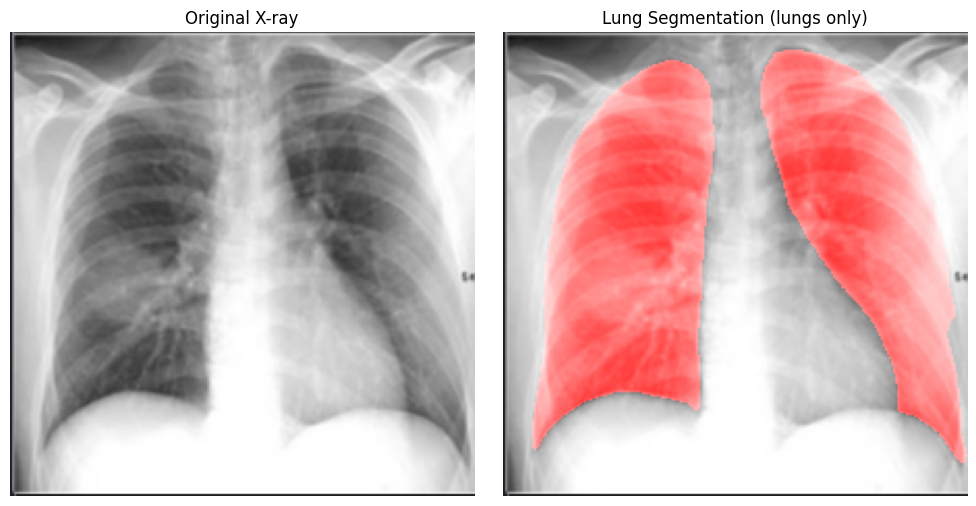

------------------------------------------------------------
XAI
------------------------------------------------------------


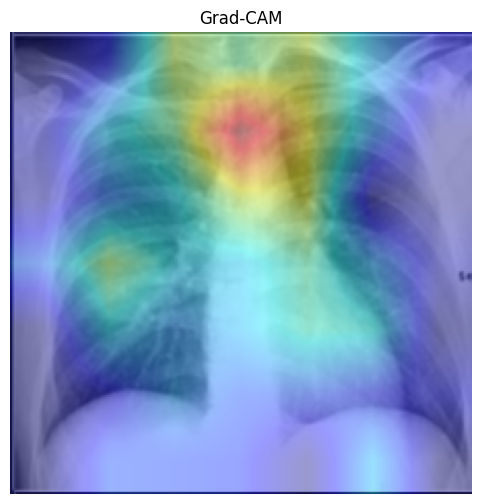

Grad-CAM/lung overlap: 48.7%
Activation region: upper-central lung field

Note: Grad-CAM shows where the classifier's attention was strongest -- it is NOT a map of the exact location of disease, a segmentation mask, a lesion mask, or a ground truth annotation. This pipeline has no disease-lesion segmentation model.

------------------------------------------------------------
AI EXPLANATION (plain language)
------------------------------------------------------------
The VLM response could not be parsed as JSON. Raw response (truncated):
   COVID: 99.96%
Lung_Opacity: 0.02%
Normal: 0.02%
Viral Pneumonia: 0.00%

This is an AI-generated interpretation and should not be considered a medical diagnosis. A qualified healthcare professional should interpret the actual X-ray.

ask_about_analysis():
 Lung opacity.

compare_xrays():
Analyzing Image 1...
[Grad-CAM] Using backbone/feature layer: 'densenet121' (output_shape=(None, 7, 7, 1024))
[Grad-CAM] Replaying 6 head layer(s) in original order:

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (8202 > 8192). Running this sequence through the model will result in indexing errors


Comparison VLM call failed: CUDA out of memory during VLM generation. Try one of: (1) reduce max_new_tokens, (2) ensure vlm_dtype is torch.bfloat16/float16 rather than float32, (3) fall back to CPU (slow but works), or (4) use a smaller VLM checkpoint.
IMAGE 1
Analysis ID: analysis_20260919_134811_3812be45   Status: partial_success

------------------------------------------------------------
CHEST X-RAY ANALYSIS
------------------------------------------------------------
Prediction: COVID
Confidence: 100.0%

Class probabilities:
  COVID              100.0%
  Lung_Opacity         0.0%
  Normal               0.0%
  Viral Pneumonia      0.0%

------------------------------------------------------------
SEGMENTATION
------------------------------------------------------------


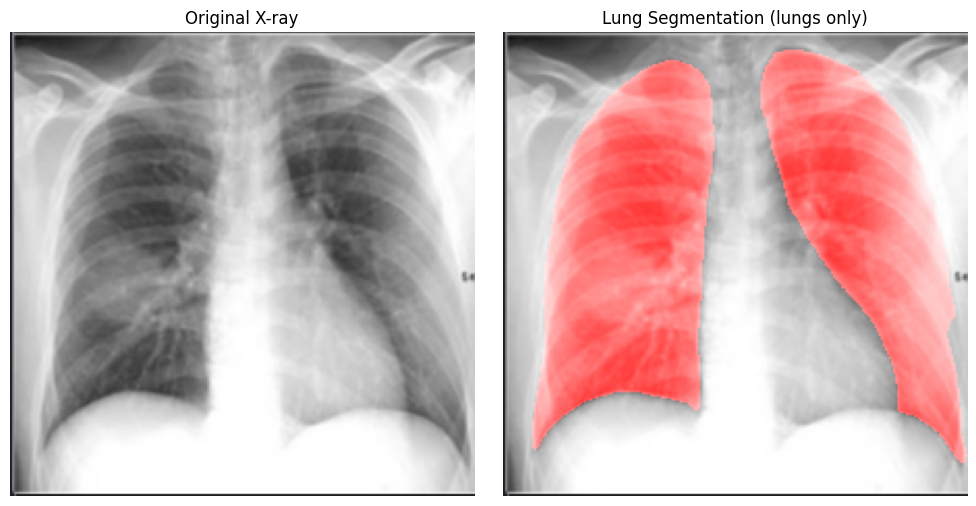

------------------------------------------------------------
XAI
------------------------------------------------------------


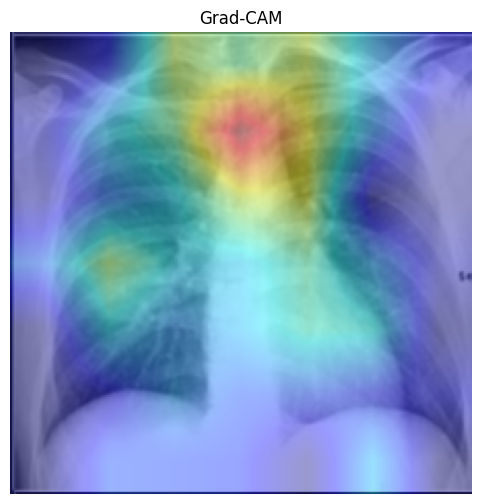

Grad-CAM/lung overlap: 48.7%
Activation region: upper-central lung field

Note: Grad-CAM shows where the classifier's attention was strongest -- it is NOT a map of the exact location of disease, a segmentation mask, a lesion mask, or a ground truth annotation. This pipeline has no disease-lesion segmentation model.

------------------------------------------------------------
AI EXPLANATION (plain language)
------------------------------------------------------------
The VLM response could not be parsed as JSON. Raw response (truncated):
   COVID: 99.96%
Lung_Opacity: 0.02%
Normal: 0.02%
Viral Pneumonia: 0.00%

This is an AI-generated interpretation and should not be considered a medical diagnosis. A qualified healthcare professional should interpret the actual X-ray.

IMAGE 2
Analysis ID: analysis_20260919_134827_37885e7a   Status: partial_success

------------------------------------------------------------
CHEST X-RAY ANALYSIS
--------------------------------------------------------

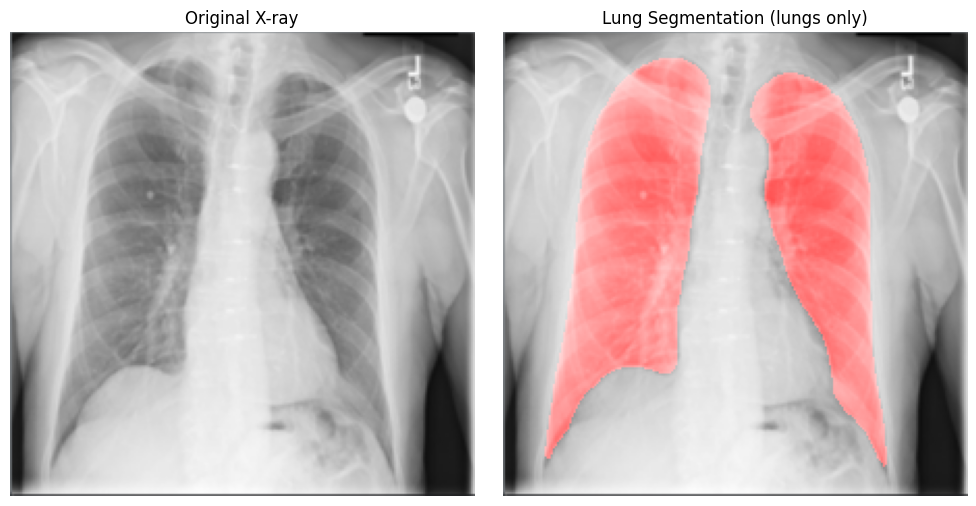

------------------------------------------------------------
XAI
------------------------------------------------------------


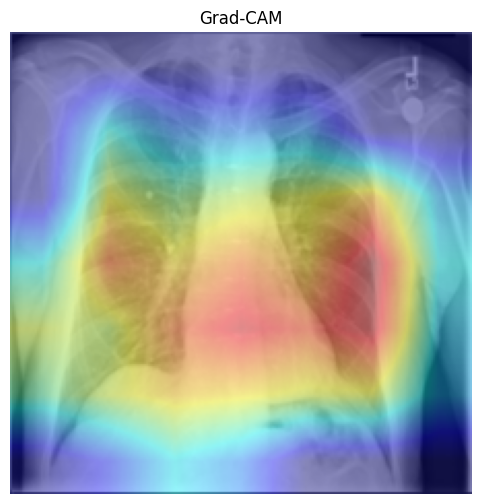

Grad-CAM/lung overlap: 40.0%
Activation region: central lung field

Note: Grad-CAM shows where the classifier's attention was strongest -- it is NOT a map of the exact location of disease, a segmentation mask, a lesion mask, or a ground truth annotation. This pipeline has no disease-lesion segmentation model.

------------------------------------------------------------
AI EXPLANATION (plain language)
------------------------------------------------------------
The VLM response could not be parsed as JSON. Raw response (truncated):
   Normal.

This is an AI-generated interpretation and should not be considered a medical diagnosis. A qualified healthcare professional should interpret the actual X-ray.

COMPARISON
Comparison unavailable (status: vlm_error): CUDA out of memory during VLM generation. Try one of: (1) reduce max_new_tokens, (2) ensure vlm_dtype is torch.bfloat16/float16 rather than float32, (3) fall back to CPU (slow but works), or (4) use a smaller VLM checkpoint.


In [28]:
# OPTIONAL TEST -- set to True and provide real image path(s) to run the expensive tests.
RUN_VLM_TEST = True
RUN_COMPARISON_TEST = True

TEST_IMAGE_PATH = "/content/Screenshot 2026-09-12 231143.png"    # replace with a real path
TEST_IMAGE_PATH_2 = "/content/Screenshot 2026-09-12 234546.png"  # replace with a second real path

if not os.path.exists(TEST_IMAGE_PATH):
    print(f"TEST_IMAGE_PATH does not exist: {TEST_IMAGE_PATH}")
    print("Set TEST_IMAGE_PATH to a real chest X-ray image (e.g. a row from your held-out "
          "test_split.csv) before running the tests below.")
else:
    print(f"Using test image: {TEST_IMAGE_PATH}\n")

    print("1) Classifier prediction")
    print("-" * 40)
    if classifier_is_available():
        print(predict_classification(TEST_IMAGE_PATH))
    else:
        print(f"SKIPPED -- classifier unavailable: {CLASSIFIER_LOAD_ERROR}")

    print("\n2) Segmentation prediction")
    print("-" * 40)
    if segmenter_is_available():
        _seg = predict_segmentation(TEST_IMAGE_PATH)
        print("mask_path:", _seg["mask_path"], " overlay_path:", _seg["overlay_path"])
    else:
        print(f"SKIPPED -- segmenter unavailable: {SEGMENTER_LOAD_ERROR}")

    print("\n3) Grad-CAM generation (verified BEFORE any VLM call)")
    print("-" * 40)
    if classifier_is_available():
        _gc = generate_gradcam(TEST_IMAGE_PATH)
        print("target_class:", _gc["target_class"], " gradcam_layer:", _gc["gradcam_layer"])
    else:
        print("SKIPPED -- classifier unavailable.")

    print("\n4) JSON parsing (parse_vlm_json)")
    print("-" * 40)
    print(parse_vlm_json('''```json\n{"summary": "ok", "limitations": "demo"}\n```'''))
    print(parse_vlm_json("not json at all"))

    print("\n5-8) Full pipeline: analyze_xray() / ask_about_analysis() / compare_xrays()")
    print("-" * 40)
    if RUN_VLM_TEST:
        test_result = analyze_xray(TEST_IMAGE_PATH)
        display_analysis(test_result)

        print("\nask_about_analysis():")
        answer = ask_about_analysis(test_result, "Where did the model focus, and why?")
        print(answer.get("answer", answer))

        if RUN_COMPARISON_TEST and os.path.exists(TEST_IMAGE_PATH_2):
            print("\ncompare_xrays():")
            comparison = compare_xrays(TEST_IMAGE_PATH, TEST_IMAGE_PATH_2)
            display_comparison(comparison)
        elif RUN_COMPARISON_TEST:
            print(f"RUN_COMPARISON_TEST is True but TEST_IMAGE_PATH_2 does not exist: {TEST_IMAGE_PATH_2}")
    else:
        print("RUN_VLM_TEST is False -- skipping the expensive VLM end-to-end tests. "
              "Set RUN_VLM_TEST = True above (and RUN_COMPARISON_TEST = True for the "
              "two-image comparison) to actually run them against real image paths.")


## 26. CPU Performance Test

New section — this is the key experimental question for this notebook: is
SmolVLM-500M practical on CPU for the future FastAPI deployment? Times each stage
of the pipeline separately, plus the full `analyze_xray()` pass, averaged over
several runs.

In [29]:
def approx_memory_usage_mb():
    # Approximate current process peak RSS memory in MB, using the stdlib `resource`
    # module (no extra dependency like psutil required). On Linux ru_maxrss is reported in
    # KB; on macOS it is reported in bytes -- both are normalized to MB here. Returns None
    # if unavailable (e.g. on Windows, where the `resource` module does not exist).
    try:
        usage = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
        return usage / (1024 * 1024) if sys.platform == "darwin" else usage / 1024
    except Exception:
        return None


def run_cpu_performance_test(image_path, n_runs=3):
    if not os.path.exists(image_path):
        print(f"CPU performance test skipped -- image not found: {image_path}")
        return None

    timings = {"classification": [], "segmentation": [], "gradcam": [], "vlm": [], "total_pipeline": []}

    print(f"Running {n_runs} end-to-end pass(es) on: {image_path}\n")
    for i in range(n_runs):
        t_total0 = time.time()

        t0 = time.time(); predict_classification(image_path); timings["classification"].append(time.time() - t0)
        t0 = time.time(); predict_segmentation(image_path); timings["segmentation"].append(time.time() - t0)
        t0 = time.time(); generate_gradcam(image_path); timings["gradcam"].append(time.time() - t0)

        result = analyze_xray(image_path)
        vlm_result = result.get("vlm", {})
        if vlm_result.get("status") == "success" and "_inference_time_sec" in vlm_result:
            timings["vlm"].append(vlm_result["_inference_time_sec"])

        timings["total_pipeline"].append(time.time() - t_total0)
        print(f"  Run {i + 1}/{n_runs} done ({timings['total_pipeline'][-1]:.2f}s total)")

    def _avg(lst):
        return sum(lst) / len(lst) if lst else None

    report = {k: _avg(v) for k, v in timings.items()}
    report["n_runs"] = n_runs
    report["approx_memory_mb"] = approx_memory_usage_mb()

    print()
    print("=" * 30)
    print("CPU PERFORMANCE")
    print("=" * 30)
    for stage, label in [("classification", "Classification"), ("segmentation", "Segmentation"),
                          ("gradcam", "Grad-CAM"), ("vlm", "SmolVLM"), ("total_pipeline", "Total")]:
        val = report[stage]
        print(f"{label:<14}: {val:.2f} sec" if val is not None else f"{label:<14}: N/A")
    print()
    print("VLM model:")
    print("SmolVLM-500M-Instruct")
    print()
    print(f"Device: {DEVICE.upper()}")
    if report["approx_memory_mb"] is not None:
        print(f"Approx. process memory (peak RSS): {report['approx_memory_mb']:.0f} MB")
    print("=" * 30)

    return report


if os.path.exists(TEST_IMAGE_PATH):
    performance_report = run_cpu_performance_test(TEST_IMAGE_PATH, n_runs=3)
else:
    performance_report = None
    print(f"TEST_IMAGE_PATH not found ({TEST_IMAGE_PATH}) -- skipping CPU performance test.")


Running 3 end-to-end pass(es) on: /content/Screenshot 2026-09-12 231143.png

[Grad-CAM] Using backbone/feature layer: 'densenet121' (output_shape=(None, 7, 7, 1024))
[Grad-CAM] Replaying 6 head layer(s) in original order: gap -> batch_normalization -> dropout -> dense -> dropout_1 -> predictions
[Grad-CAM] Using backbone/feature layer: 'densenet121' (output_shape=(None, 7, 7, 1024))
[Grad-CAM] Replaying 6 head layer(s) in original order: gap -> batch_normalization -> dropout -> dense -> dropout_1 -> predictions
  Run 1/3 done (16.52s total)
[Grad-CAM] Using backbone/feature layer: 'densenet121' (output_shape=(None, 7, 7, 1024))
[Grad-CAM] Replaying 6 head layer(s) in original order: gap -> batch_normalization -> dropout -> dense -> dropout_1 -> predictions
[Grad-CAM] Using backbone/feature layer: 'densenet121' (output_shape=(None, 7, 7, 1024))
[Grad-CAM] Replaying 6 head layer(s) in original order: gap -> batch_normalization -> dropout -> dense -> dropout_1 -> predictions
  Run 2/3 don

## 27. Failure Handling

New section — explicitly demonstrates that the pipeline degrades gracefully: a VLM
load/inference failure, or `VLM_ENABLED = False`, never crashes classification,
segmentation, or Grad-CAM.

In [30]:
def simulate_vlm_disabled_run(image_path):
    # Force VLM_ENABLED = False for one run and confirm the rest of the pipeline still
    # works end-to-end and reports vlm.status == "disabled" rather than crashing.
    global VLM_ENABLED
    original_flag = VLM_ENABLED
    VLM_ENABLED = False
    try:
        result = analyze_xray(image_path)
        assert result["vlm"]["status"] == "disabled"
        print("VLM-disabled run OK -- classification, segmentation, and Grad-CAM still ran.")
        print(f"  Predicted class: {result['classification']['predicted_class']}")
        print(f"  VLM status     : {result['vlm']['status']}")
        return result
    finally:
        VLM_ENABLED = original_flag


def simulate_vlm_failure(image_path):
    # Temporarily point VLM_MODEL_NAME at an invalid model id to force a VLM load
    # failure, then confirm analyze_xray() still returns classification/segmentation/
    # Grad-CAM results with vlm.status == "vlm_error" instead of crashing the whole
    # pipeline (IMPROVEMENT 11).
    global VLM_MODEL_NAME, vlm_model, vlm_processor, VLM_LOAD_ERROR
    original_name = VLM_MODEL_NAME
    original_model, original_processor, original_error = vlm_model, vlm_processor, VLM_LOAD_ERROR
    try:
        VLM_MODEL_NAME = "this/model-does-not-exist"
        vlm_model = None
        vlm_processor = None
        load_smolvlm()  # expected to fail and set VLM_LOAD_ERROR
        result = analyze_xray(image_path)
        print(f"Simulated failure -- VLM status: {result['vlm']['status']}")
        print(f"  Message: {result['vlm'].get('error') or result['vlm'].get('message')}")
        print(f"  Classification still returned: {result['classification']['predicted_class']}")
        return result
    finally:
        VLM_MODEL_NAME = original_name
        vlm_model = original_model
        vlm_processor = original_processor
        VLM_LOAD_ERROR = original_error


if os.path.exists(TEST_IMAGE_PATH):
    print("--- VLM disabled run ---")
    simulate_vlm_disabled_run(TEST_IMAGE_PATH)
    print("\n--- VLM failure simulation ---")
    simulate_vlm_failure(TEST_IMAGE_PATH)
    print("\n--- Memory cleanup ---")
    clear_gpu_memory()
else:
    print(f"TEST_IMAGE_PATH not found ({TEST_IMAGE_PATH}) -- skipping failure-handling smoke tests.")


--- VLM disabled run ---
[Grad-CAM] Using backbone/feature layer: 'densenet121' (output_shape=(None, 7, 7, 1024))
[Grad-CAM] Replaying 6 head layer(s) in original order: gap -> batch_normalization -> dropout -> dense -> dropout_1 -> predictions
VLM-disabled run OK -- classification, segmentation, and Grad-CAM still ran.
  Predicted class: COVID
  VLM status     : disabled

--- VLM failure simulation ---
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `hf auth login` or by passing `token=<your_token>`
Classification, segmentation, and Grad-CAM will still work fully. VLM-dependent calls will return a 'vlm_unavailable'/'vlm_error' status instead of crashing (IMPROVEMENT 11).
[Grad-CAM] Using backbone/feature layer: 'densenet121' (output_shape=(None, 7, 7, 1024))
[Grad-CAM] Replaying 6 head layer(s) in original order: gap -> batch_normalization -> dropout -> dense -> dropout_1 -> predictions
VLM generation failed: VLM unav

## 28. Final Validation

In [31]:
def final_validation_report():
    checks = {
        "Classification working": False,
        "Segmentation working": False,
        "Grad-CAM working": False,
        "Evidence generation working": False,
        "VLM inference working": False,
        "Q&A working": False,
        "Comparison working": False,
    }
    vlm_times = []
    r = None

    if os.path.exists(TEST_IMAGE_PATH):
        try:
            predict_classification(TEST_IMAGE_PATH)
            checks["Classification working"] = True
        except Exception:
            pass
        try:
            predict_segmentation(TEST_IMAGE_PATH)
            checks["Segmentation working"] = True
        except Exception:
            pass
        try:
            generate_gradcam(TEST_IMAGE_PATH)
            checks["Grad-CAM working"] = True
        except Exception:
            pass
        try:
            _, _val_dir = new_analysis_dir()
            create_vlm_evidence_images(TEST_IMAGE_PATH, _val_dir)
            checks["Evidence generation working"] = True
        except Exception:
            pass

        if VLM_ENABLED and vlm_is_available():
            try:
                r = analyze_xray(TEST_IMAGE_PATH)
                checks["VLM inference working"] = r["vlm"].get("status") == "success"
                if r["vlm"].get("_inference_time_sec"):
                    vlm_times.append(r["vlm"]["_inference_time_sec"])
            except Exception:
                r = None
            if r is not None:
                try:
                    qa = ask_about_analysis(r, "What did the AI predict?")
                    checks["Q&A working"] = qa.get("status") == "success"
                    if qa.get("inference_time_sec"):
                        vlm_times.append(qa["inference_time_sec"])
                except Exception:
                    pass

        if os.path.exists(TEST_IMAGE_PATH_2):
            try:
                comp = compare_xrays(TEST_IMAGE_PATH, TEST_IMAGE_PATH_2)
                checks["Comparison working"] = comp["comparison"].get("status") == "success"
            except Exception:
                pass

    avg_vlm_time = sum(vlm_times) / len(vlm_times) if vlm_times else None
    core = list(checks.values())

    if not os.path.exists(TEST_IMAGE_PATH):
        overall = "INCOMPLETE (TEST_IMAGE_PATH not found)"
    elif all(core):
        overall = "PASS"
    elif any(core):
        overall = "PARTIAL"
    else:
        overall = "FAIL"

    print("=" * 40)
    print("SMOLVLM-500M VALIDATION")
    print("=" * 40)
    print(f"Model loaded: {'YES' if vlm_is_available() else 'NO'}" if VLM_ENABLED else "Model loaded: N/A (VLM_ENABLED=False)")
    print(f"Device: {DEVICE.upper()}")
    for label, val in checks.items():
        print(f"{label}: {'YES' if val else 'NO'}")
    print()
    print(f"Average VLM inference time: {avg_vlm_time:.2f} sec" if avg_vlm_time else "Average VLM inference time: N/A")
    mem = approx_memory_usage_mb()
    print(f"Approximate memory usage: {mem:.0f} MB (peak RSS)" if mem else "Approximate memory usage: N/A")
    print()
    print("Overall result:")
    print(overall)
    print("=" * 40)

    return {"checks": checks, "avg_vlm_inference_time_sec": avg_vlm_time, "overall": overall}


validation_report = final_validation_report()


[Grad-CAM] Using backbone/feature layer: 'densenet121' (output_shape=(None, 7, 7, 1024))
[Grad-CAM] Replaying 6 head layer(s) in original order: gap -> batch_normalization -> dropout -> dense -> dropout_1 -> predictions
[Grad-CAM] Using backbone/feature layer: 'densenet121' (output_shape=(None, 7, 7, 1024))
[Grad-CAM] Replaying 6 head layer(s) in original order: gap -> batch_normalization -> dropout -> dense -> dropout_1 -> predictions
[Grad-CAM] Using backbone/feature layer: 'densenet121' (output_shape=(None, 7, 7, 1024))
[Grad-CAM] Replaying 6 head layer(s) in original order: gap -> batch_normalization -> dropout -> dense -> dropout_1 -> predictions
Analyzing Image 1...
[Grad-CAM] Using backbone/feature layer: 'densenet121' (output_shape=(None, 7, 7, 1024))
[Grad-CAM] Replaying 6 head layer(s) in original order: gap -> batch_normalization -> dropout -> dense -> dropout_1 -> predictions
Analyzing Image 2...
[Grad-CAM] Using backbone/feature layer: 'densenet121' (output_shape=(None, 7,

## 29. Final Output Report

In [32]:
print("=" * 60)
print("FINAL REPORT")
print("=" * 60)
print(f"SmolVLM model used       : {VLM_MODEL_NAME}")
print(f"VLM model class used     : {VLM_MODEL_CLASS_USED}" if VLM_MODEL_CLASS_USED else "VLM model class used     : N/A")
print(f"Transformers version     : {transformers.__version__}")
print(f"PyTorch version          : {torch.__version__}")
print(f"TensorFlow version       : {tf.__version__}")
print(f"Device used              : {DEVICE.upper()}")
print(f"VLM load time            : {vlm_load_time:.2f} sec" if vlm_load_time else "VLM load time            : N/A")

if performance_report:
    vlm_avg = performance_report.get("vlm")
    total_avg = performance_report.get("total_pipeline")
    print(f"Avg VLM inference time   : {vlm_avg:.2f} sec" if vlm_avg else "Avg VLM inference time   : N/A")
    print(f"Avg total pipeline time  : {total_avg:.2f} sec" if total_avg else "Avg total pipeline time  : N/A")
    if total_avg is not None:
        if total_avg < 15:
            practicality = "likely practical for interactive use"
        elif total_avg < 45:
            practicality = "borderline -- usable but noticeably slow for interactive use"
        else:
            practicality = "likely too slow for interactive use; consider async/background processing"
        print(f"CPU practicality         : {practicality} (~{total_avg:.1f}s/image end-to-end)")
else:
    print("Avg VLM inference time   : N/A (CPU Performance Test not run)")
    print("Avg total pipeline time  : N/A (CPU Performance Test not run)")

mem = approx_memory_usage_mb()
print(f"Approx. memory usage     : {mem:.0f} MB (peak RSS)" if mem else "Approx. memory usage     : N/A")
print(f"Overall validation       : {validation_report['overall']}")
print()
print("Limitations:")
print("- Grad-CAM assumes a linear head after the backbone in the classifier's layer list")
print("  (auto-detected via _find_backbone_layer() / head-layer replay) -- if your")
print("  classifier's head branches, adapt generate_gradcam() accordingly.")
print("- Grad-CAM/lung overlap is a purely geometric, activation-weighted comparison --")
print("  it is NOT a disease-localization accuracy score.")
print("- CPU inference time for SmolVLM-500M scales with max_new_tokens and image count;")
print("  the numbers above use this notebook's default settings (3 evidence images,")
print("  max_new_tokens=512 for the structured explanation).")
print()
print("Recommendation for future FastAPI deployment:")
print("- If the CPU timings and memory above are acceptable for your target hardware and")
print("  usage pattern, load_smolvlm() / run_smolvlm_chat() / parse_vlm_json() from this")
print("  notebook can be lifted directly into the server.")
print("- If CPU latency is too high, consider: SmolVLM-256M-Instruct, reducing")
print("  max_new_tokens, reducing evidence-image resolution, or quantized/ONNX export as")
print("  follow-up experiments before building the server.")
print("=" * 60)
print()
print("This notebook is a validation experiment only.")
print("DO NOT build the FastAPI + React server until this notebook passes.")


FINAL REPORT
SmolVLM model used       : HuggingFaceTB/SmolVLM-500M-Instruct
VLM model class used     : AutoModelForImageTextToText
Transformers version     : 5.16.1
PyTorch version          : 2.11.0+cu128
TensorFlow version       : 2.20.0
Device used              : CUDA
VLM load time            : 18.87 sec
Avg VLM inference time   : N/A
Avg total pipeline time  : 15.91 sec
CPU practicality         : borderline -- usable but noticeably slow for interactive use (~15.9s/image end-to-end)
Approx. memory usage     : 4569 MB (peak RSS)
Overall validation       : PARTIAL

Limitations:
- Grad-CAM assumes a linear head after the backbone in the classifier's layer list
  (auto-detected via _find_backbone_layer() / head-layer replay) -- if your
  classifier's head branches, adapt generate_gradcam() accordingly.
- Grad-CAM/lung overlap is a purely geometric, activation-weighted comparison --
  it is NOT a disease-localization accuracy score.
- CPU inference time for SmolVLM-500M scales with max_ne